# **StockGuard_for_youtube**
2022105468 소프트웨어융합학과 송예지

### **0. 환경 설정**

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
from pathlib import Path

plt.rcParams['font.family'] = 'NanumGothic' # 한글 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

DB_PATH = Path('/home/songyaeji/stockguard_for_youtube/data/youtube_channels.db')
conn = sqlite3.connect(DB_PATH)

### **1. 데이터 load**

In [2]:
df_channels = pd.read_sql('SELECT * FROM channels', conn)
df_videos   = pd.read_sql('SELECT * FROM videos', conn)
df_comments = pd.read_sql('SELECT * FROM comments', conn)

### **2. 연구 가설**
모델 전 가설 확정 — EDA(3장)·전처리(4장)는 아래 가설의 feature·근거를 탐색·정제하는 단계.

**모집단**: "30개 주식 키워드로 검색된 채널" 2,508개(경제유튜브 전체 아님 → 선택편향). 분석 단위 = **채널**(리딩방 = 채널).

| 가설 | 주장 | 방법 | 판정 기준 |
|---|---|---|---|
| **H1** 지도학습 분류 | 리딩방은 규제키워드 없이도 행동·구조 패턴만으로 판별 가능 | holdout 분류 | recall·F1 |
| **H2** 비지도 PCA+군집 | 작전성 채널이 별도 군집으로 분리 | PCA→클러스터링 | 시드라벨 일치도(ARI·purity) |
| **H3** 통계검정 | 의심군 참여율·시황민감도 ≠ 정상군 | t-test/ANOVA | 유의수준 0.05 + 효과크기 |

**핵심 원칙**
- **라벨 leakage 금지**: `search_query`·`query_group` → 분류 입력 feature 제외(평가·시드라벨로만).
- **anomaly = 타겟**: 리딩방·봇·유령은 정상분포 이탈 = 탐지 대상 → 삭제 X, **flag 보존**(Retention).
- **regex ≠ ML**: 규제 키워드는 라벨 근거라 feature 금지 / URL·연락처는 *형식* 정규식이라 feature 허용.
- **기각도 결과**: 가설 기각 시에도 정당한 insight


### **3. EDA(Exploratory Data Analysis)**

#### 3-1. Comprehensive Data Exploration
`info()`·`describe()`로 3개 테이블의 구조·타입·결측을 한 번에 파악

In [3]:
# 데이터 개수 확인
print(f"채널: {df_channels.shape[0]:,} rows × {df_channels.shape[1]} cols")
print(f"영상: {df_videos.shape[0]:,} rows × {df_videos.shape[1]} cols")
print(f"댓글: {df_comments.shape[0]:,} rows × {df_comments.shape[1]} cols")

채널: 2,508 rows × 14 cols
영상: 34,162 rows × 13 cols
댓글: 423,522 rows × 9 cols


In [4]:
print("----------df_channels 데이터 맛보기----------")
display(df_channels.head(1))
print("----------df_videos 데이터 맛보기----------")
display(df_videos.head(1))
print("----------df_comments 데이터 맛보기----------")
display(df_comments.head(1))

----------df_channels 데이터 맛보기----------


,channel_id,title,description,custom_url,country,language,subscriber_count,video_count,view_count,published_at,thumbnail_url,search_query,collected_at,videos_fetched
0,UCzcy0PURMktW2BBgNpih-rw,청담개미여왕,"❌️리딩방, 후원요구채널 아닙니다.❌️\n주식정보 찐맛집!!\n안전하고 꾸준하게 주...",@cheongdam_queenant,,,83,35,36736,2025-06-15T11:41:08.17101Z,https://yt3.ggpht.com/VjQXF-XOKdfwNmxJZJg4RgKH...,주식리딩방,2026-06-02T12:24:07.760332+00:00,1


----------df_videos 데이터 맛보기----------


,video_id,channel_id,title,description,published_at,view_count,like_count,comment_count,duration_seconds,thumbnail_url,collected_at,comments_disabled,comments_fetched
0,lp4FzVNTRFQ,UC---QNKc1l1dp4XmbnAi9lQ,가난하다고 절대 좌절하면 안되는이유,안녕하세요. 익절 박아주는 남자 익박남입니다\n\n익빡남 무료타점방 입장 :\nht...,2026-05-08T08:39:05Z,34,4,1,171,https://i.ytimg.com/vi/lp4FzVNTRFQ/default.jpg,2026-06-02T12:25:58.972364+00:00,0,1


----------df_comments 데이터 맛보기----------


,comment_id,video_id,channel_id,author,text,like_count,published_at,collected_at,parent_id
0,UgwfVzvaxyKdp5mxJ3t4AaABAg,dbyjQlAvSNk,UC---QNKc1l1dp4XmbnAi9lQ,@익빡남,익빡남 무료 타점방 입장 : https://forms.gle/zya57ooVj6d4...,0,2026-04-27T08:36:56Z,2026-06-03T08:53:15.132192+00:00,NaN


##### 3-1-1. df_channels
| 컬럼 | 의미 | 관찰 | 결론 |
|---|---|---|---|
| `channel_id` | 채널 고유 ID(PK) | object, non-null 2,508 | PK 무결. 식별자 → 분석 feature 제외 |
| `title` | 채널명 | object, non-null 2,508 | NLP·중복점검 대상, 수치 분석 제외 |
| `description` | 채널 설명글 | non-null 2,508(빈문자 결측은 info 미포착) | NLP 분석 + NULL 값을 빈 값으로 확인(4-1) |
| `custom_url` | @핸들 형태 URL | non-null 2,508, title과 일치할 확률 높아보임 | title 일치율 측정 후 삭제 판단 |
| `country` | 국가코드 | 한국 대상으로 크롤링했는데 다른 국가코드도 보임 | KR `is_kr` 이진분류 예정(4-1) |
| `language` | 채널 언어 | non-null 2,508(빈문자 미포착) | 실제 결측 규모 확인(3-2-4) 후 과다면 feature 제외 |
| `subscriber_count` | 구독자수 | 평균 36,744 ≫ 중앙 59.5, max 410만 → 강한 우편향 | log1p 등의 전처리 필요(3-2-1) |
| `video_count` | 채널 총 영상수 | 평균 512 ≫ 중앙 24, max 10.2만 → 강한 우편향 | log1p + IQR 점검(삭제 X·플래그, 4-3) |
| `view_count` | 채널 누적 조회수 | 평균 884만 ≫ 중앙 1.3만, max 18.8억 → 강한 우편향 | log1p + 조회0 flag + IQR 점검(삭제 X·플래그, 4-3) |
| `published_at` | 채널 개설일 | object(문자열) → datetime 아님 | `datetime` 변환 후 시간 분석(3-2-5) |
| `thumbnail_url` | 프로필 이미지 URL | 이미지 링크 | 수치 분석 제외 |
| `search_query` | 수집 검색어 | 직접 만든 검색어 30개 | **leakage 방지 위해 분류 입력 feature 금지** |
| `collected_at` | 수집 시각 | object(문자열) | `datetime` 변환 후 시간 분석(3-2-5) |
| `videos_fetched` | 크롤링 시도 flag | 크롤링 시 중복 방지용 flag | 분석 feature 제외 |


In [5]:
df_channels.info()
df_channels[['subscriber_count','video_count','view_count']].describe() # 수치형 데이터만 요약 통계

<class 'pandas.DataFrame'>
RangeIndex: 2508 entries, 0 to 2507
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   channel_id        2508 non-null   str  
 1   title             2508 non-null   str  
 2   description       2508 non-null   str  
 3   custom_url        2508 non-null   str  
 4   country           2508 non-null   str  
 5   language          2508 non-null   str  
 6   subscriber_count  2508 non-null   int64
 7   video_count       2508 non-null   int64
 8   view_count        2508 non-null   int64
 9   published_at      2508 non-null   str  
 10  thumbnail_url     2508 non-null   str  
 11  search_query      2508 non-null   str  
 12  collected_at      2508 non-null   str  
 13  videos_fetched    2508 non-null   int64
dtypes: int64(4), str(10)
memory usage: 274.4 KB


,subscriber_count,video_count,view_count
count,2.508000e+03,2508.000000,2.508000e+03
mean,3.674420e+04,511.669059,8.840102e+06
std,2.039118e+05,3467.745690,7.872604e+07
min,0.000000e+00,0.000000,0.000000e+00
25%,2.000000e+00,5.000000,5.692500e+02
50%,5.950000e+01,24.000000,1.316550e+04
75%,3.202500e+03,169.000000,2.764282e+05
max,4.100000e+06,101522.000000,1.877501e+09


##### 3-1-2. df_videos
| 컬럼 | 의미 | 관찰 | 결론 |
|---|---|---|---|
| `video_id` | 영상 고유 ID(PK) | non-null 34,162 | PK 무결. 식별자 → feature 제외 |
| `channel_id` | 소속 채널 ID(FK) | non-null 34,162 | 채널 단위 집계 키(4-4) |
| `title` | 영상 제목 | non-null 34,162 | NLP·중복점검, 수치 제외 |
| `description` | 영상 설명문 | non-null 34,162(빈문자 미포착) | NULL 값을 빈 값으로 확인(4-1) |
| `published_at` | 업로드일 | object(문자열) → datetime 아님 | `datetime` 변환 |
| `view_count` | 영상 조회수 | 평균 8,997 ≫ 중앙 441, max 1,050만 → 강한 우편향 | IQR outlier 우선 + log1p. 참여비율 계산(3-2-3) |
| `like_count` | 좋아요수 | 평균 167 ≫ 중앙 5, max 4.99만 → 강한 우편향 | log1p + 조회수 보정 비율 계산 `like_rate`(3-2-3) |
| `comment_count` | 댓글수 | 평균 13.3, **중앙 0·하위 75%까지 ≤2**(과반 0), max 6,856 → 0-과잉 | 0/비0 분리 + log1p. 0 원인 = `comments_disabled` 교차 확인 |
| `duration_seconds` | 영상 길이(초) | 중앙 186, 평균 1,290, max 42,901(≈12시간) → 강한 우편향, 라이브 혼재 의심 | shorts/일반/라이브 분류 필요→ `is_short`(4-3) |
| `thumbnail_url` | 썸네일 URL | 이미지 링크 | 수치 제외 |
| `collected_at` | 수집 시각 | object(문자열) → datetime 아님 | `datetime` 변환 |
| `comments_disabled` | 댓글 차단 여부(0/1) | non-null 34,162 | 범주형 확인 필요(3-2-4). `comment_count`=0 구조적 원인으로 구분할 필요 있음 |
| `comments_fetched` | 크롤링 시도 flag | 크롤링 시 중복 방지용 flag | 분석 feature 제외 |


In [6]:
df_videos.info()
df_videos[['view_count','like_count','comment_count','duration_seconds']].describe() # 수치형 데이터만 요약 통계

<class 'pandas.DataFrame'>
RangeIndex: 34162 entries, 0 to 34161
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   video_id           34162 non-null  str  
 1   channel_id         34162 non-null  str  
 2   title              34162 non-null  str  
 3   description        34162 non-null  str  
 4   published_at       34162 non-null  str  
 5   view_count         34162 non-null  int64
 6   like_count         34162 non-null  int64
 7   comment_count      34162 non-null  int64
 8   duration_seconds   34162 non-null  int64
 9   thumbnail_url      34162 non-null  str  
 10  collected_at       34162 non-null  str  
 11  comments_disabled  34162 non-null  int64
 12  comments_fetched   34162 non-null  int64
dtypes: int64(6), str(7)
memory usage: 3.4 MB


,view_count,like_count,comment_count,duration_seconds
count,3.416200e+04,34162.000000,34162.000000,34162.000000
mean,8.996862e+03,166.827030,13.282243,1290.165125
std,1.083920e+05,968.884591,96.788119,4275.864635
min,0.000000e+00,0.000000,0.000000,0.000000
25%,5.700000e+01,0.000000,0.000000,44.000000
50%,4.410000e+02,5.000000,0.000000,186.000000
75%,1.942750e+03,30.000000,2.000000,828.750000
max,1.050501e+07,49900.000000,6856.000000,42901.000000


##### 3-1-3. df_comments
| 컬럼 | 의미 | 관찰 | 결론 |
|---|---|---|---|
| `comment_id` | 댓글 고유 ID(PK) | non-null 423,522 | PK 무결. 식별자 → feature 제외 |
| `video_id` | 소속 영상 FK | non-null 423,522 | 영상 단위 집계 키 |
| `channel_id` | 소속 채널 FK | non-null 423,522 | 채널 단위 집계 키(4-4) |
| `parent_id` | 부모(최상위) 댓글 ID | **non-null 118,906 → NaN 71.9%** (info가 잡은 유일한 실결측값) | 최상위 댓글은 정의상 부모 없음(구조적) → `is_reply` flag 생성(4-1) 필요, 분석에 필요한 결측값 |
| `author` | 작성자명 | non-null 423,522 | NLP·중복점검(소수 작성자 도배 = 봇·작전 신호) |
| `text` | 댓글 내용 | non-null 423,522 | NLP 핵심. 동일문구 반복 = 도배·봇 신호 |
| `like_count` | 댓글 좋아요수 | 평균 4 ≫ 중앙 1, 하위 25%=0, max 4,372 → 우편향+0 다수 | log1p + 0/비0 분리 검토(3-2-1) |
| `published_at` | 작성일 | object(문자열) → datetime 아님 | `datetime` 변환 |
| `collected_at` | 수집 시각 | object(문자열) → datetime 아님 | `datetime` 변환 |


In [7]:
df_comments.info()
df_comments[['like_count']].describe() # 수치형 데이터만 요약 통계

<class 'pandas.DataFrame'>
RangeIndex: 423522 entries, 0 to 423521
Data columns (total 9 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   comment_id    423522 non-null  str  
 1   video_id      423522 non-null  str  
 2   channel_id    423522 non-null  str  
 3   author        423522 non-null  str  
 4   text          423522 non-null  str  
 5   like_count    423522 non-null  int64
 6   published_at  423522 non-null  str  
 7   collected_at  423522 non-null  str  
 8   parent_id     118906 non-null  str  
dtypes: int64(1), str(8)
memory usage: 29.1 MB


,like_count
count,423522.000000
mean,4.041346
std,30.197555
min,0.000000
25%,0.000000
50%,1.000000
75%,2.000000
max,4372.000000


#### 3-2. Exploring Attributes
변수를 **하나씩** 보며 각 feature 분포·특성을 확인(변수 *사이* 관계는 3-3). 수치형 → 파생 feature → 범주형 → 시간 → 파생 시간 attribute → 텍스트 순.

**결론 요약**: 수치형은 전부 우편향+0-과잉 → log1p·flag로 처리(4장). 파생 feature 사용. 모집단 = 주식 키워드 검색 채널(선택편향) → 일반화 한계 전제.

##### 3-2-1. Descriptive Statistics - 수치형 Attributes
**목적**: 수치형 8컬럼의 중심경향·변동성·분포형태를 한 표로 파악.

**방법** — 지표 읽는 법 + 판정 2축

| 지표 | 뜻 | 읽기 | 주의 |
|---|---|---|---|
| 평균·중앙값 | 중심 | 평균≫중앙값 = 우편향 | 우편향 시 평균 대표성 X → 중앙값 |
| 0비율% | 0 비중 | 0-과잉 규모 | 0 많으면 변환으로 안 펴짐 |
| 표준편차·IQR | 흩어짐(분산의 √) | 절대 퍼짐 정도 | 단위에 묶임 → 변수끼리 비교 X |
| CV (=표준편차/평균) | 상대 흩어짐 | 단위 약분 → 변수끼리 비교 가능 | 극단치에 취약 → 참고용 |
| QCD (=(Q3−Q1)/(Q3+Q1)) | 분위 흩어짐 | 가운데 50%만 봐 극단치에 강건 | outlier 남기는 본 데이터엔 우선 지표 |
| skewness | 치우침 | >0 우편향, \|값\|>1 강함 → log1p | - |
| kurtosis | 꼬리 두께 | >0 정규보다 꼬리 두꺼움 | 극단 1개에도 폭등 → max/P99로 보조 |
| max/P99 (최댓값/99분위) | 극단치 쏠림 | 큼=소수 극단치가 통계 주도(outlier 후보) | 정식 판정은 1.5×IQR(4-2) |

판정 2축 — **0비율**: 중앙값=0(0비율≥50%)이면 0/비0 분리, 미만은 0이 구조적(댓글차단·미집계)인지 확인 후 처리 / **max/P99**: 클수록 1.5×IQR outlier 비중↑(4-2), 작으면 log1p만으로 충분.

**결과**

| 변수 | 0비율 | 중앙값 | skewness | kurtosis | max/P99 | 판정·조치 |
|---|---|---|---|---|---|---|
| channels `subscriber_count` | 17.5% | 59.5 | 11.85 | 176.5 | 6.1 | 우편향+0-과잉 |
| channels `video_count` | 3.7% | 24.0 | 21.92 | 570.7 | 14.0 | 극단치 쏠림 큼 |
| channels `view_count` | 11.0% | 13,165.5 | 16.94 | 333.6 | 10.4 | 우편향+0-과잉+극단치 |
| videos `view_count` | 4.4% | 441.0 | 55.62 | 4,092.6 | **73.8** | 극단치 최악 |
| videos `like_count` | 25.6% | 5.0 | 20.70 | 664.7 | 15.3 | 0-과잉+극단치 |
| videos `comment_count` | **53.5%** | **0.0** | 31.70 | 1,630.8 | 30.6 | 과반 0 |
| videos `duration_seconds` | 0.6% | 186.0 | 6.37 | 45.7 | **1.7** | 꼬리 고름 |
| comments `like_count` | 48.6% | 1.0 | 44.87 | 3,552.5 | **78.1** | 0-과잉+극단치 |

**결론**
- 전 컬럼 강한 우편향(skewness 6~56) → 평균 무의미, 중앙값·분위수로 해석, 전부 `log1p`(4-2).
- 변동성도 일관: CV 3.3~12배·QCD 0.90~1.00 = 극단치 뺀 가운데 50%조차 넓게 퍼지고 0에 쏠림(QCD≈1.00은 Q1=0 뜻) → log1p + 0/비0 분리가 합리적.
- `comment_count`(중앙 0)·comments `like_count`(0비율 48.6%) = 0-과잉 커 **0/비0 분리** 필수. videos `view_count`·comments `like_count`는 max/P99 70+ → **IQR outlier 우선**. `duration_seconds`만 max/P99 1.7 → log1p로 충분.
- 단 표만으론 0이 실제 부재(미수집)인지·극단값이 target인지·outlier 경계는 미결 → 0초과 분포(3-2-2)·라벨 대조(4-3)·1.5×IQR(4-2)서 확인.


In [8]:
def describe_numeric(df, cols):
    """수치형 요약통계 표. pandas/scipy 내장 함수만 사용(직접 구현 X)."""
    d = df[cols]
    base = d.describe(percentiles=[.25, .5, .75, .90, .99]).T
    q1, q3 = base['25%'], base['75%']
    out = pd.DataFrame({
        '개수'       : base['count'].astype(int),
        '평균'     : base['mean'].round(1),
        '중앙값'   : base['50%'].round(1),
        '0비율%'  : (d == 0).mean().mul(100).round(1), # 0-과잉 규모(0 쏠림 정도)
        '표준편차' : base['std'].round(1),
        'IQR'     : d.apply(stats.iqr).round(1),
        'CV'      : d.apply(lambda s: stats.variation(s, ddof=1)).round(2),
        'QCD'     : ((q3 - q1) / (q3 + q1)).round(2), #(Q3-Q1)/(Q3+Q1)
        'skewness': d.apply(lambda s: stats.skew(s, bias=False)).round(2),
        'kurtosis': d.apply(lambda s: stats.kurtosis(s, bias=False)).round(2),
        'P90'     : base['90%'].round(1),
        'P99'     : base['99%'].round(1),
        'max/P99' : (base['max'] / base['99%']).round(1), #kurtosis 보조 지표. outlier 영향 vs 우편향 진단
    }).replace([np.inf, -np.inf], np.nan)
    sty = out.rename_axis('속성').reset_index().style.hide(axis='index')
    fmt = {col: '{:,.2f}' for col in out.columns if col != '개수'}  # 수치 2자리(콤마)
    fmt['개수'] = '{:,}'
    return sty.format(fmt)

ch_num  = ['subscriber_count','video_count','view_count']
vid_num = ['view_count','like_count','comment_count','duration_seconds']
cm_num  = ['like_count']

print('[channels]'); display(describe_numeric(df_channels, ch_num))
print('[videos]');   display(describe_numeric(df_videos, vid_num))
print('[comments]'); display(describe_numeric(df_comments, cm_num))

[channels]


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
subscriber_count,"2,508","36,744.20",59.50,17.50,"203,911.80","3,200.50",5.55,1.00,11.85,176.50,"40,710.00","675,620.00",6.10
video_count,"2,508",511.70,24.00,3.70,"3,467.70",164.00,6.78,0.94,21.92,570.69,904.30,"7,249.10",14.00
view_count,"2,508","8,840,101.70","13,165.50",11.00,"78,726,035.60","275,859.00",8.91,1.00,16.94,333.56,"3,896,301.20","180,020,338.00",10.40


[videos]


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
view_count,"34,162","8,996.90",441.00,4.40,"108,392.00","1,885.80",12.05,0.94,55.62,"4,092.61","8,695.90","142,255.90",73.80
like_count,"34,162",166.80,5.00,25.60,968.90,30.00,5.81,1.00,20.70,664.71,243.00,"3,263.60",15.30
comment_count,"34,162",13.30,0.00,53.50,96.80,2.00,7.29,1.00,31.70,"1,630.83",17.00,224.40,30.60
duration_seconds,"34,162","1,290.20",186.00,0.60,"4,275.90",784.80,3.31,0.90,6.37,45.72,"1,929.00","25,931.30",1.70


[comments]


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
like_count,"423,522",4.00,1.00,48.60,30.20,2.00,7.47,1.00,44.87,"3,552.52",6.00,56.00,78.10


##### 3-2-2. Data Visualization - 수치형 Attributes
**목적**: log1p 처리로 충분한지, 0/비0 분리를 해야 하는지 판단.

**방법**: ①원본 histogram(빈도 log축) ②boxplot ③log1p 변환본(0초과만) 3개 그림 비교. 판정 = ③의 *0초과 skewness* — |값|<0.5면 종모양(log1p 충분), 여전히 크면 log로 안 펴짐(0-과잉이 본질 → 0/비0 분리).

**결과**

| 변수 | 전체 skewness | 0비율 | 0초과 skewness | 판정 |
|---|---|---|---|---|
| channels `subscriber_count` | 11.85 | 17.5% | 0.32 | log1p 충분 |
| channels `video_count` | 21.92 | 3.7% | 0.58 | log1p 충분 |
| channels `view_count` | 16.94 | 11.0% | **0.01** | log1p로 완전 대칭화 |
| videos `view_count` | 55.62 | 4.4% | **0.02** | log1p로 완전 대칭화 |
| videos `like_count` | 20.70 | 25.6% | 0.90 | log1p + 0비율 잔존 → 비율 계산 필요(3-2-3) |
| videos `comment_count` | 31.70 | **53.5%** | **1.25** | log로도 안 펴짐 → 0/비0 분리 |
| videos `duration_seconds` | 6.37 | 0.6% | 0.15 | log1p 충분 |
| comments `like_count` | 44.87 | 48.6% | **1.83** | log로도 안 펴짐 → 0/비0 분리 |

**결론**
- 원본은 전부 0 근처 한 봉우리 + 긴 꼬리(강한 우편향). log1p 뒤 대부분 skewness 0 근처로 퍼짐 → log1p 잘 듣는 변수.
- 단 `comment_count=0`(53.5%)·comments `like_count=0`(48.6%)는 변환 뒤에도 우편향(1.25·1.83) 잔존 → **0/비0 분리**가 더 적합. `like_count`도 log1p 후 0.90+0비율 잔존 = 규모 보정만으론 부족.
- 변환으로 안 풀리는 두 갈래 분기 — 조회수 종속(`like_count`)·0-과잉(`comment_count`)은 **3-2-3 참여 비율**로, log1p·flag·outlier는 **4장**으로.


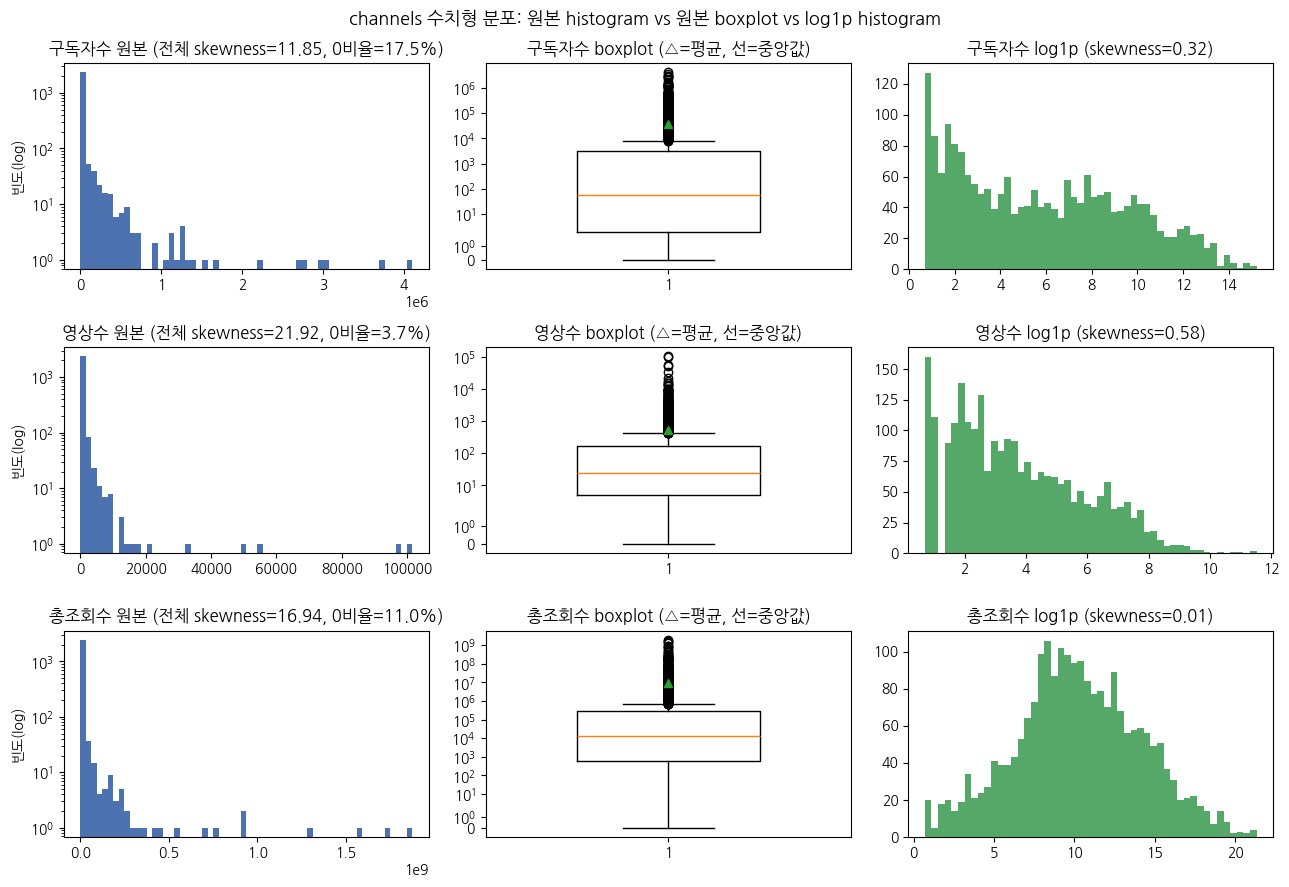

In [9]:
def dist_grid(df, cols, label_map, title):
    n = len(cols)
    fig, axes = plt.subplots(n, 3, figsize=(13, 3*n))
    if n == 1: axes = axes.reshape(1, -1)
    for i, c in enumerate(cols):
        s = df[c].astype(float)
        pos = s[s > 0]
        zero_pct = (s == 0).mean() * 100
        axes[i,0].hist(s, bins=60, color='#4c72b0'); axes[i,0].set_yscale('log')
        axes[i,0].set_title(f'{label_map[c]} 원본 (전체 skewness={s.skew():.2f}, 0비율={zero_pct:.1f}%)')
        axes[i,0].set_ylabel('빈도(log)')
        axes[i,1].boxplot(s, vert=True, widths=0.5, showmeans=True); axes[i,1].set_yscale('symlog')
        axes[i,1].set_title(f'{label_map[c]} boxplot (△=평균, 선=중앙값)')
        sl = np.log1p(pos)
        axes[i,2].hist(sl, bins=50, color='#55a868')
        axes[i,2].set_title(f'{label_map[c]} log1p (skewness={sl.skew():.2f})')
    fig.suptitle(title, fontsize=13); plt.tight_layout(); plt.show()

dist_grid(df_channels, ch_num,
          {'subscriber_count':'구독자수','video_count':'영상수','view_count':'총조회수'},
          'channels 수치형 분포: 원본 histogram vs 원본 boxplot vs log1p histogram')

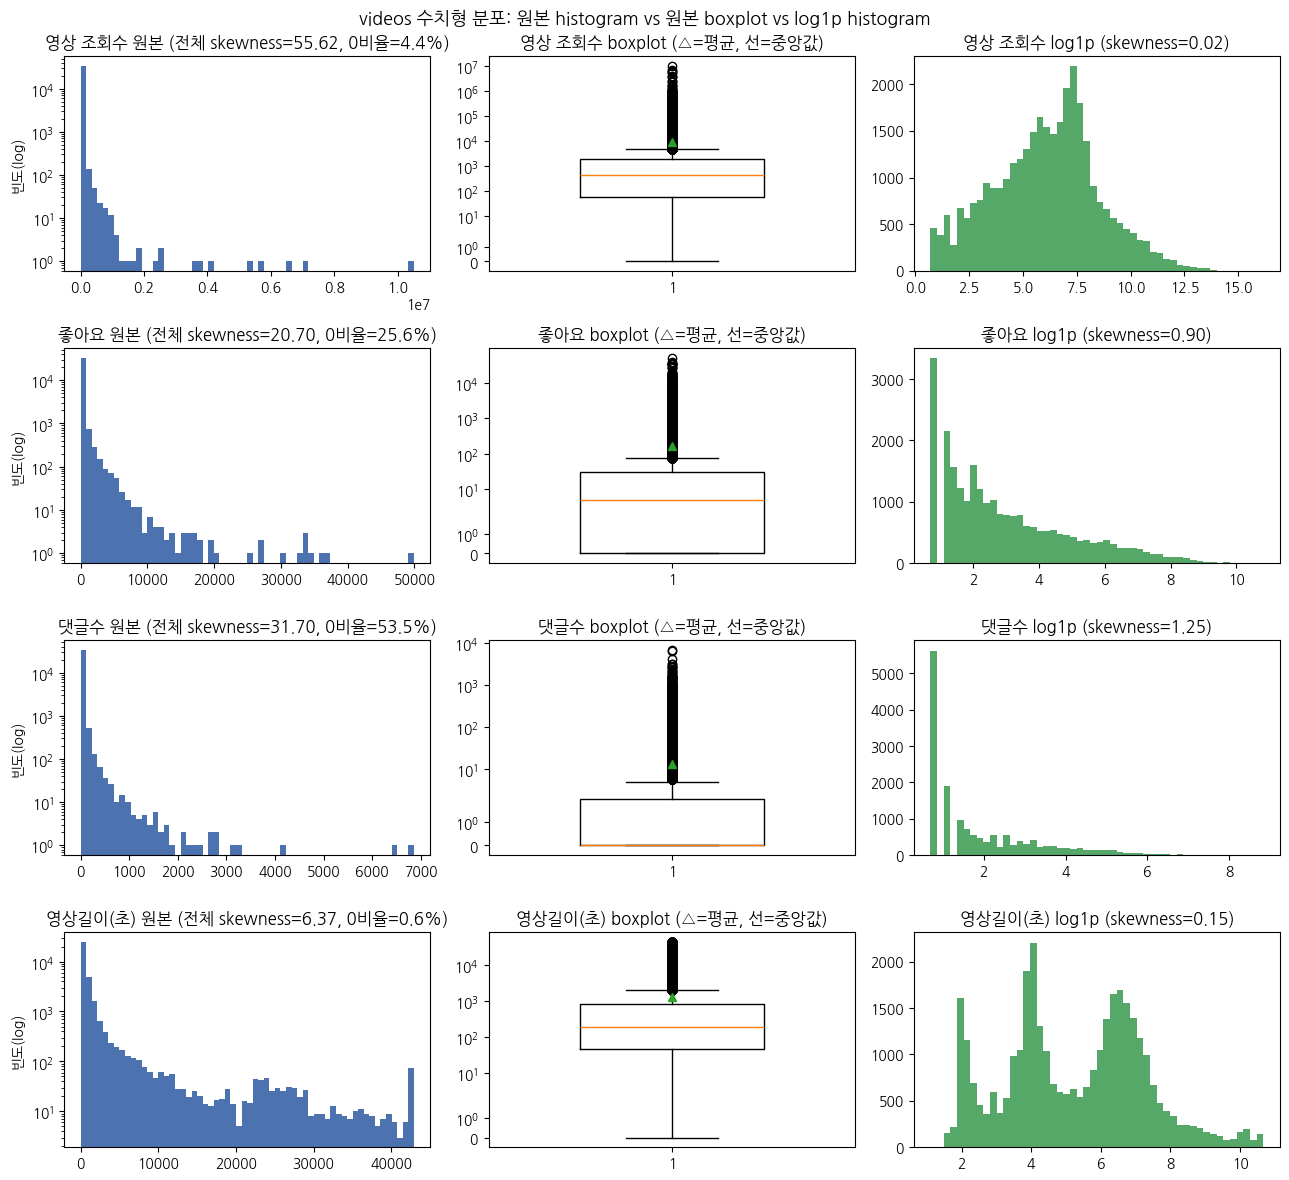

In [10]:
dist_grid(df_videos, vid_num,
          {'view_count':'영상 조회수','like_count':'좋아요','comment_count':'댓글수','duration_seconds':'영상길이(초)'},
          'videos 수치형 분포: 원본 histogram vs 원본 boxplot vs log1p histogram')

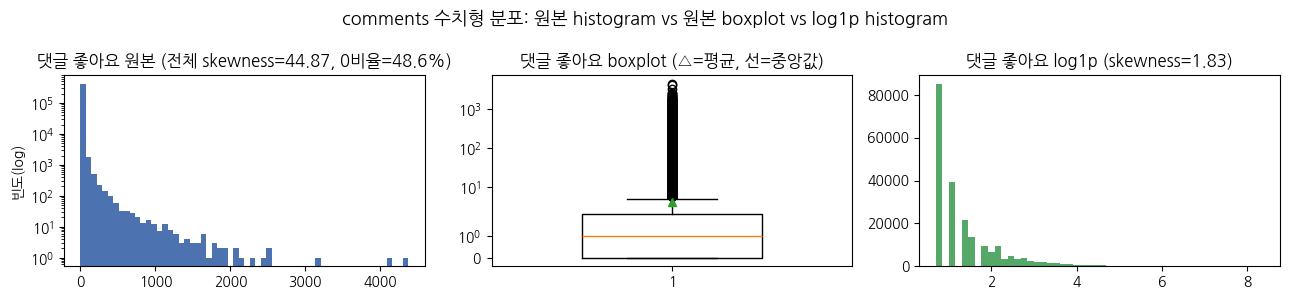

In [11]:
dist_grid(df_comments, cm_num,
          {'like_count':'댓글 좋아요'},
          'comments 수치형 분포: 원본 histogram vs 원본 boxplot vs log1p histogram')

##### 3-2-3. 참여 비율 - 수치형 파생 Attributes
**목적**: 3-2-2서 `like_count`(log1p 후 skew 0.90+0비율 25.6%)·`comment_count`(1.25)는 규모 보정만으론 부족 — 둘 다 **조회수 종속**(조회 100만 영상 좋아요 1,000 ≠ 조회 2,000 영상 좋아요 1,000)이라 절대수는 규모효과지 참여의 질 아님. 조회수로 나눈 **참여율** 도입해 채널 간 비교 가능.

**방법**: `like_rate = like/view`·`comment_rate = comment/view`(유튜브 표준 지표). `view=0`(1,492개·4.4%)은 비율 정의 불가 + 도메인상 view=0인데 좋아요·댓글 있으면 anomaly → **비율 계산서만 제외**(관측 보존은 4-3). 비율도 우편향이라 log1p축으로 형태 확인.

**결과** (view>0 = 32,670 / 34,162 영상)

| 지표 | 중앙값 | P99 | >1(비정상) |
|---|---|---|---|
| like_rate | 0.014 | 0.27 | 19개 |
| comment_rate | 0.000 | 0.25 | 5개 |

**결론**
- 두 파생변수 `like_rate`·`comment_rate` 모두 생성·채택 = 규모효과 제거된 참여 지표
- `like_rate`: 0비율 22.4%로 적음 → **log1p**만으로 충분
- `comment_rate`: 과반 0(51.9%) → **0/비0 분리(has_comment flag + 비0 log1p)** 후 사용. 변수 폐기 아님, 0-과잉만 분해
- 비율>1 비정상값(like_rate 19개·comment_rate 5개)는 **anomaly flag로 보존(4-3)**


비율 계산 대상(view>0): 32,670 / 34,162 영상
like_rate>1 (좋아요>조회, 비정상): 19개
comment_rate>1: 5개


속성,개수,평균,중앙값,0비율%,표준편차,IQR,CV,QCD,skewness,kurtosis,P90,P99,max/P99
like_rate,"32,670",0.00,0.00,22.40,0.10,0.00,3.01,0.95,36.81,"2,312.02",0.10,0.30,30.80
comment_rate,"32,670",0.00,0.00,51.90,0.10,0.00,6.21,1.00,14.03,280.27,0.00,0.20,12.00


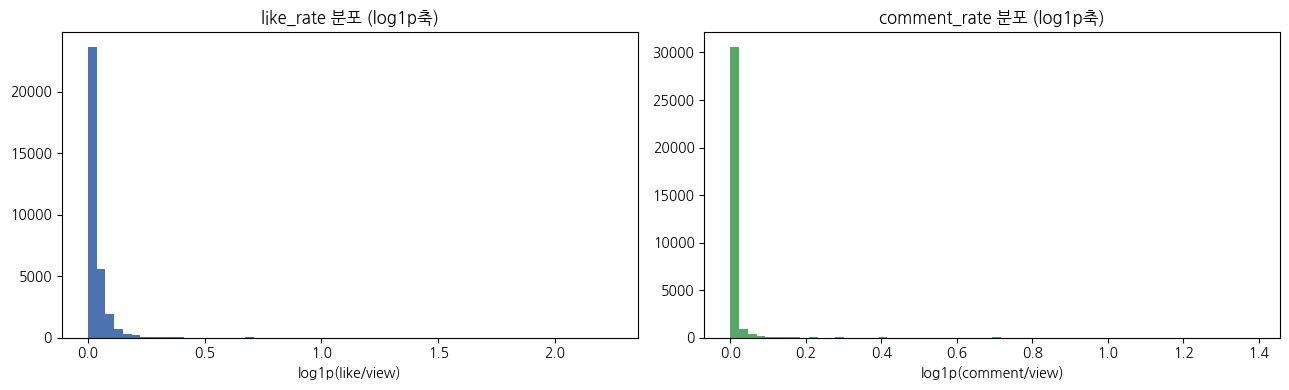

In [12]:
# 조회수>0 영상만
v = df_videos[df_videos['view_count'] > 0].copy()
v['like_rate']    = v['like_count']    / v['view_count']
v['comment_rate'] = v['comment_count'] / v['view_count']

print(f"비율 계산 대상(view>0): {len(v):,} / {len(df_videos):,} 영상")
print(f"like_rate>1 (좋아요>조회, 비정상): {int((v['like_rate']>1).sum())}개")
print(f"comment_rate>1: {int((v['comment_rate']>1).sum())}개")
display(describe_numeric(v, ['like_rate', 'comment_rate']))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
# 비율도 우편향 → log1p 축으로 형태 확인
ax[0].hist(np.log1p(v['like_rate']),    bins=60, color='#4c72b0')
ax[0].set_title('like_rate 분포 (log1p축)');    ax[0].set_xlabel('log1p(like/view)')
ax[1].hist(np.log1p(v['comment_rate']), bins=60, color='#55a868')
ax[1].set_title('comment_rate 분포 (log1p축)'); ax[1].set_xlabel('log1p(comment/view)')
plt.tight_layout(); plt.show()

##### 3-2-4. Frequency - 범주형 Attributes
**목적**: 범주형은 평균·분산이 무의미 → 값별 빈도·고유값으로 파악. 더해 (1) `info()`가 못 잡는 빈문자(`''`) 숨은 결측 가시화, (2) `comments_disabled`로 `comment_count`=0의 구조적 원인(차단 vs 참여없음) 분리.

**방법**: 빈 문자열은 `(빈값)`으로 치환해 결측처럼 노출, value_counts로 분포 확인. 수치형 `duration_seconds`는 길이 형식(Shorts/일반/장문)으로 구간화해 범주형으로 다룸(Shorts 기준 = YouTube 정책 180s, 2024-10-15 변경).

**결과**

| 변수 | 분포 | 관찰 |
|---|---|---|
| `country` (채널) | 고유 11. KR 1,337(53.3%) / (빈값) 1,126(44.9%) / US 26 / 그외 극소수 | KR·빈값 양분, 해외 무시 가능 |
| `language` (채널) | 고유 5. (빈값) 2,425(96.7%) / ko 79 / 그외 4 | 거의 전부 미기재 |
| `search_query` (채널) | 30종 전부 등장, 채널당 45~98개(중앙 87)로 고름 | 크롤링 시 설계 의도대로 |
| `comments_disabled` (영상) | 0=31,736 / 1=2,426(7.1%) | 소수만 댓글 차단 |
| `duration`→형식 (영상) | ≤180s Shorts 49.7% / 3~10분 17.1% / 10~30분 22.5% / >30분 10.7% | 단타 미끼 vs 장문 혼재 |
*YouTube Shorts 정책에 따라 Shorts는 3분 이하 영상으로 분류

**결론**
- `country` → KR/비KR 이진 분류 `is_kr`(4-1).
- `language` → 결측 96.7%로 정보가치 거의 없음 → **feature 제외** 확정
- `search_query` → 균등 분포라 빈도 자체는 정보가치 없음 + **분류 입력 feature 금지(leakage)**. 평가·시드라벨로만 사용하자
- `comments_disabled` → `comment_count`=0의 구조적 원인 구분 키. 차단 7.1% vs 비차단 분리 필요 → `has_comment` flag와 교차(4-1).
- 영상 길이 형식 → Shorts(≤180s) 49.7% = 단타 미끼 비중 큼. `is_short`(≤180s) flag 파생(4-3). 장문(>30분 10.7%)엔 라이브 다시보기 혼재.

[country] 고유값 11개 / 최빈값: KR (1,337)
country
KR      1337
(빈값)    1126
US        26
IN         8
AU         4
GB         2
NZ         1
HK         1
Name: count, dtype: int64

[language] 고유값 5개 / 최빈값: (빈값) (2,425)
language
(빈값)     2425
ko         79
hi          2
en          1
en-IN       1
Name: count, dtype: int64

[search_query] 고유값 30개 / 최빈값: 급등주 (98)

[comments_disabled] 고유값 2개 / 최빈값: 0 (31,736)
comments_disabled
0    31736
1     2426
Name: count, dtype: int64
[country] 고유값 11개 / 최빈값: KR (1,337)


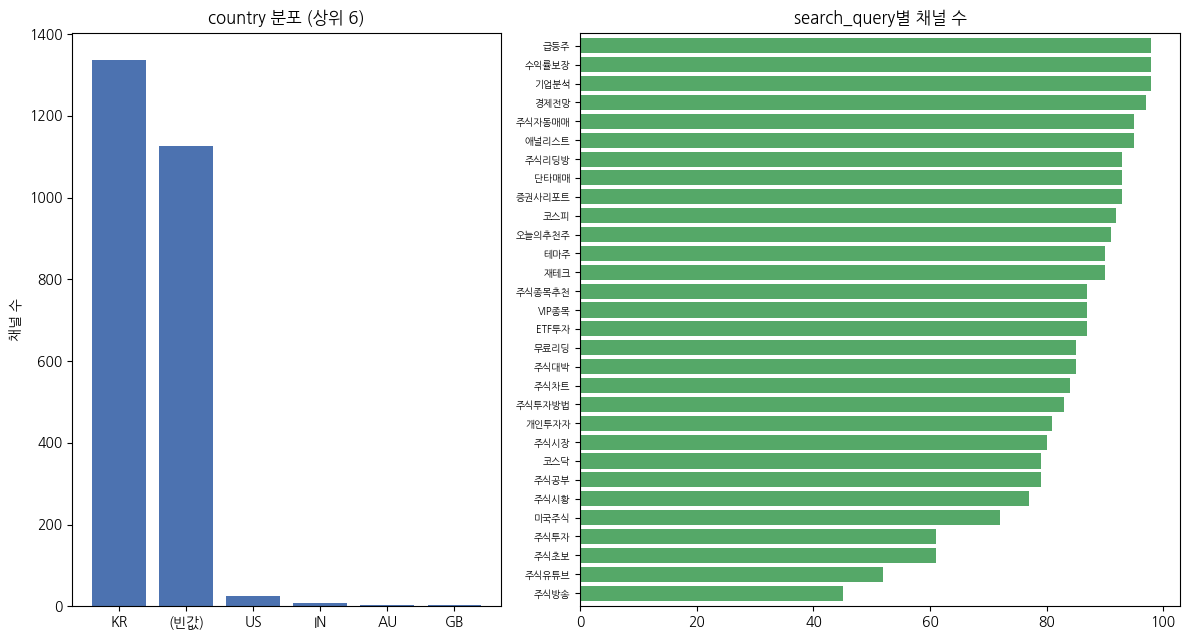


[영상 길이 형식]
duration_seconds
≤180s(Shorts)    16986
3~10분             5851
10~30분            7673
>30분              3652
Name: count, dtype: int64
Shorts 정책(180s) 변경일 2024-10-15 이후 업로드: 84.7%


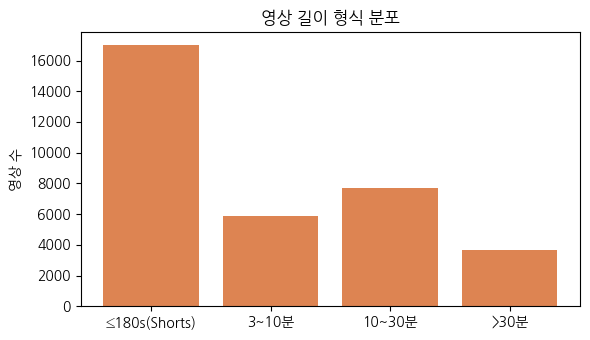

In [13]:
def show_categorical(s, name, top=None):
    s = s.fillna('').astype(str).str.strip().replace('', '(빈값)')
    vc = s.value_counts()
    print(f'[{name}] 고유값 {s.nunique()}개 / 최빈값: {vc.index[0]} ({vc.iloc[0]:,})')
    return vc.head(top) if top else vc

# country (채널, 숨은 결측 가시화)
print(show_categorical(df_channels['country'], 'country').head(8)); print()
# language (채널, 숨은 결측 가시화)
print(show_categorical(df_channels['language'], 'language').head(6)); print()
# search_query (채널, 수집 키워드 30종)
sq = show_categorical(df_channels['search_query'], 'search_query', top=30); print()
# comments_disabled (영상)
print(show_categorical(df_videos['comments_disabled'], 'comments_disabled'))

# search_query 30종 → 가로 막대 라벨 겹침 방지: 높이 확보 + 폰트 축소
fig, ax = plt.subplots(1, 2, figsize=(12, 6.5), gridspec_kw={'width_ratios': [1, 1.4]})
cc = show_categorical(df_channels['country'], 'country').head(6)
ax[0].bar(cc.index, cc.values, color='#4c72b0'); ax[0].set_title('country 분포 (상위 6)')
ax[0].set_ylabel('채널 수')
ax[1].barh(sq.index[::-1], sq.values[::-1], color='#55a868'); ax[1].set_title('search_query별 채널 수')
ax[1].tick_params(axis='y', labelsize=7); ax[1].margins(y=0.01)
plt.tight_layout(); plt.show()

# 영상 길이 형식 (duration_seconds → 범주 파생: Shorts/일반/장문)
# YouTube Shorts 정책 = 180s(2024-10-15 변경). 데이터 84.7%가 정책 후 업로드 → 180s 기준
dur_bucket = pd.cut(df_videos['duration_seconds'], [-1, 180, 600, 1800, np.inf],
                    labels=['≤180s(Shorts)', '3~10분', '10~30분', '>30분'])
db = dur_bucket.value_counts().reindex(['≤180s(Shorts)', '3~10분', '10~30분', '>30분'])
print('\n[영상 길이 형식]'); print(db)
_vp = pd.to_datetime(df_videos['published_at'], format='ISO8601', utc=True)
print(f'Shorts 정책(180s) 변경일 2024-10-15 이후 업로드: {(_vp >= pd.Timestamp("2024-10-15", tz="UTC")).mean()*100:.1f}%')
fig2, ax2 = plt.subplots(figsize=(6, 3.5))
ax2.bar(db.index, db.values, color='#dd8452'); ax2.set_title('영상 길이 형식 분포'); ax2.set_ylabel('영상 수')
plt.tight_layout(); plt.show()

##### 3-2-5. 시간 분포 - 시간 Attributes
**목적**: 문자열 날짜를 `datetime` 변환 후 채널 개설·영상 업로드 시간 분포 확인. 이유 = (1) 신규 채널 유입 추세 파악(리딩방 급증 시점 단서), (2) 표본 시점 편향 인지(raw 카운트 나이보정의 근거), **(3) 업로드 시각대 = 시황 민감도(H3) 단서**. 변수 간 관계는 3-3.

**결과**

| 대상 | 범위 | 관찰 |
|---|---|---|
| 채널 개설 | 2005-11 ~ 2026-06 | 2026년 930개(전체 37%)·2025년 352개 → **최근 급증**, 절반(52%)이 1.5년 내 신설 |
| 영상 업로드 | 2009-02 ~ 2026-06 | 최근 3개월 63.8% / 12개월 80.9% → **극단 최근 편중** |
| 업로드 시각(KST) | 0~23시 | 18시 모드 9.2%, 장중(9~15시) 32.2% / 장마감후(16~20시) 38.2%, 주말 20.8% |

**결론**
- `published_at` → `datetime` 변환 확정. 채널 개설일에서 채널 나이 feature(`channel_age`) 파생 가능.
- 영상 업로드 최근 편중 → **나이보정 `video_age_days` 필수(3-2-6)**. 크롤링 규칙(최신순 영상 20개 수집)과 일치
- 2026년 채널 개설 급증(37%) = 리딩방 신생 가설 후보 feature로 놓고 살펴보기
- 업로드 18시 집중·장마감후(16~20시) 38.2% → **장 마감 후 다음날 종목 띄우기 의심**(H3 시황민감도 단변량 근거). 그룹 간 비교는 H3 본분석.

채널 개설: 최초 2005-11-17 ~ 최근 2026-06-02
영상 업로드: 최초 2009-02-15 ~ 최근 2026-06-03
영상 최근 3개월(age<=90일) 63.8% / 12개월(<=365일) 80.9%
채널 개설 2026년 930개(37%) / 2025년 352개 / 1.5년내 신설 52%


/tmp/ipykernel_99435/2927960049.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  vid_dt.dt.to_period('M').value_counts().sort_index().tail(24).plot(kind='bar', ax=ax[1], color='#55a868')


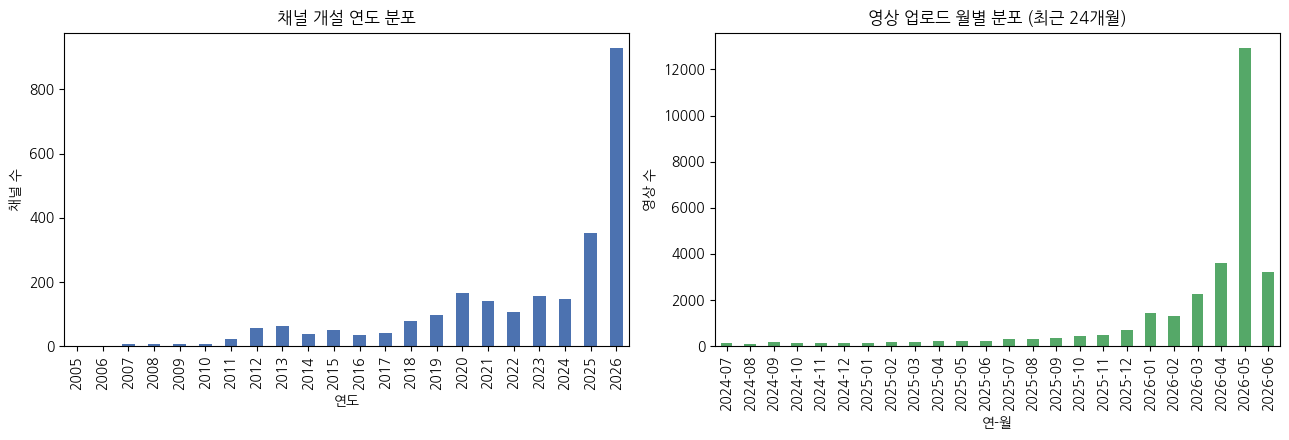

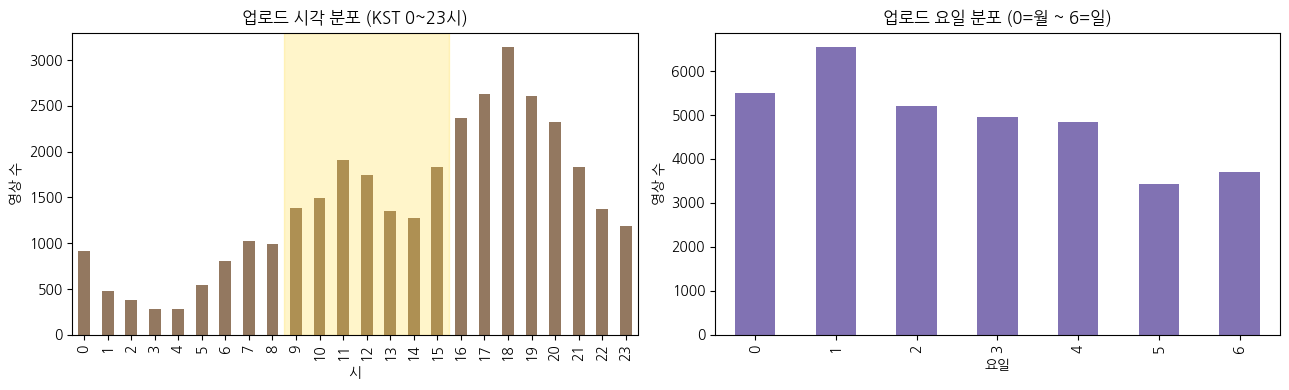

업로드 18시 9.2% / 장중(9~15시) 32.2% / 장마감후(16~20시) 38.2% / 주말 20.8%


In [14]:
ch_dt  = pd.to_datetime(df_channels['published_at'], format='ISO8601', utc=True)
vid_dt = pd.to_datetime(df_videos['published_at'],   format='ISO8601', utc=True)

print('채널 개설: 최초', ch_dt.min().date(), '~ 최근', ch_dt.max().date())
print('영상 업로드: 최초', vid_dt.min().date(), '~ 최근', vid_dt.max().date())
# 프로즈 수치 재현: 업로드 최근 편중(영상 나이 기준) + 채널 개설 연도/신생 비율
_vage = (pd.to_datetime(df_videos['collected_at'], format='ISO8601', utc=True) - vid_dt).dt.total_seconds() / 86400
print(f'영상 최근 3개월(age<=90일) {(_vage<=90).mean()*100:.1f}% / 12개월(<=365일) {(_vage<=365).mean()*100:.1f}%')
_cyr = ch_dt.dt.year.value_counts()
_cage = (pd.to_datetime(df_channels['collected_at'], format='ISO8601', utc=True) - ch_dt).dt.total_seconds() / 86400
print(f'채널 개설 2026년 {int(_cyr.get(2026,0))}개({_cyr.get(2026,0)/len(ch_dt)*100:.0f}%) / 2025년 {int(_cyr.get(2025,0))}개 / 1.5년내 신설 {(_cage<=547.5).mean()*100:.0f}%')

fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ch_dt.dt.year.value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4c72b0')
ax[0].set_title('채널 개설 연도 분포'); ax[0].set_xlabel('연도'); ax[0].set_ylabel('채널 수')
vid_dt.dt.to_period('M').value_counts().sort_index().tail(24).plot(kind='bar', ax=ax[1], color='#55a868')
ax[1].set_title('영상 업로드 월별 분포 (최근 24개월)'); ax[1].set_xlabel('연-월'); ax[1].set_ylabel('영상 수')
plt.tight_layout(); plt.show()

# 업로드 시각대(KST) — H3 시황 민감도 단변량 근거 (장중 9~15시 vs 장마감후)
vid_kst = vid_dt.dt.tz_convert('Asia/Seoul')
hr = vid_kst.dt.hour
fig2, ax2 = plt.subplots(1, 2, figsize=(13, 4))
hr.value_counts().sort_index().plot(kind='bar', ax=ax2[0], color='#937860')
ax2[0].set_title('업로드 시각 분포 (KST 0~23시)'); ax2[0].set_xlabel('시'); ax2[0].set_ylabel('영상 수')
ax2[0].axvspan(8.5, 15.5, color='#ffd92f', alpha=0.25)  # 장중 9~15시 음영
vid_kst.dt.weekday.value_counts().sort_index().plot(kind='bar', ax=ax2[1], color='#8172b3')
ax2[1].set_title('업로드 요일 분포 (0=월 ~ 6=일)'); ax2[1].set_xlabel('요일'); ax2[1].set_ylabel('영상 수')
plt.tight_layout(); plt.show()
print(f'업로드 18시 {(hr==18).mean()*100:.1f}% / 장중(9~15시) {hr.between(9,15).mean()*100:.1f}% / 장마감후(16~20시) {hr.between(16,20).mean()*100:.1f}% / 주말 {vid_kst.dt.weekday.isin([5,6]).mean()*100:.1f}%')

##### 3-2-6. 수집시점 나이 - 파생 시간 Attributes
**목적**: `collected_at − published_at`으로 영상·채널 두 나이를 파생하고, **나이가 raw 카운트(view/like/comment)를 교란하는지 점검**. 이론상 게시 후 시간이 길수록 조회가 누적되므로(1일차 100만 ≠ 5년차 100만) 나이는 잠재 **파생 시간 attribute** → 실제 데이터서 교란 정도를 확인해 보정 필요성 판단. 동시에 음수(게시>수집)로 수집 시점 정합성 점검. `collected_at`은 버리지 않고 age 파생용 보존.

**결과**

| 대상 | 중앙값 | 범위 | 음수(게시>수집=오류) |
|---|---|---|---|
| 영상 나이 | 39일 | 0 ~ 6,316일(17년) | 0개 |
| 채널 나이 | 480일(1.3년) | 0 ~ 7,502일(20.6년) | 0개 |

- 채널 1년 미만 신생 = **46.8%**(거의 절반)
- 영상 나이 vs 조회수 **Spearman ρ = −0.06**(거의 무상관)
  - *Spearman = 순위(rank) 기반 상관*: raw가 강한 우편향·극단치라 Pearson(선형·정규 가정)은 극단치에 휘둘림 → 값을 순위로 바꿔 계산하는 Spearman으로 단조 관계를 강건하게 확인(|ρ|<0.1 무상관)

**결론**
- `video_age_days` → 이 표본선 raw view 주요 교란원 **아님**(ρ≈0, 나이 구간별 조회 중앙값 534→517→338→250로 평탄·약감소 = 누적 우상향 없음, 산점도도 같은 나이서 광분산). 원인 = 3-2-5 시점 편향(수집이 최근 영상 위주 → 나이 범위 압축, 자연 누적 가려짐). 따라서 **일괄 정규화 분모로 강제하지 않음**(없는 나이의존성 인위 주입 위험). 단 속도(view/day) 논리는 유효 → 급등·단타 탐지용 **속도 파생 feature 후보**로 활용.
- `channel_age_days` → 채널 성숙도 feature. 중앙 1.3년·신생(<1년) 46.8% = 3-2-5 개설 급증의 정량 확인 → 리딩방 신생 가설 정량 근거, 신생 flag 검토. 단 최대 20.6년 노장도 공존 → 성숙도 편차 큼.
- 음수 0개 → 게시>수집 영상·채널 없음 = 수집 시점 정합성 정상, anomaly 삭제 불필요(4-3).


영상 나이  중앙 39일 / 범위 0~6316일 / 음수(오류) 0개
채널 나이  중앙 480일(1.3년) / 범위 0~7502일 / 음수(오류) 0개
1년 미만 신생 채널: 46.8%
영상 나이-조회수 Spearman rho = -0.06
나이구간별 조회수 중앙값: 0~30일 534 / 30~180일 517 / 180~365일 338 / 365일+ 250


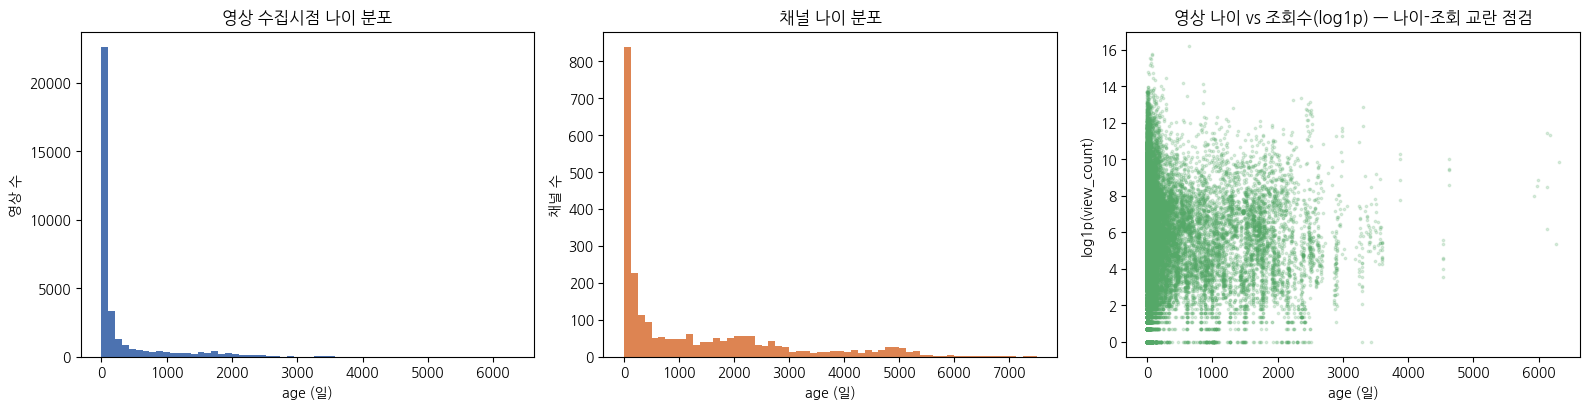

In [15]:
# 두 나이 파생: 수집시점 − 게시/개설시점
vid_age = (pd.to_datetime(df_videos['collected_at'],   format='ISO8601', utc=True)
           - pd.to_datetime(df_videos['published_at'], format='ISO8601', utc=True)).dt.total_seconds() / 86400
ch_age  = (pd.to_datetime(df_channels['collected_at'],   format='ISO8601', utc=True)
           - pd.to_datetime(df_channels['published_at'], format='ISO8601', utc=True)).dt.total_seconds() / 86400

print(f'영상 나이  중앙 {vid_age.median():.0f}일 / 범위 {vid_age.min():.0f}~{vid_age.max():.0f}일 / 음수(오류) {int((vid_age<0).sum())}개')
print(f'채널 나이  중앙 {ch_age.median():.0f}일({ch_age.median()/365:.1f}년) / 범위 {ch_age.min():.0f}~{ch_age.max():.0f}일 / 음수(오류) {int((ch_age<0).sum())}개')
print(f'1년 미만 신생 채널: {(ch_age<365).mean()*100:.1f}%')

# 나이가 raw view를 끄는지: Spearman + 나이구간별 조회 중앙값(프로즈 수치 재현용)
rho = stats.spearmanr(vid_age, df_videos['view_count']).correlation
age_bin = pd.cut(vid_age, [0, 30, 180, 365, np.inf], labels=['0~30일','30~180일','180~365일','365일+'], right=False)
vmed = df_videos['view_count'].groupby(age_bin, observed=True).median()
print(f'영상 나이-조회수 Spearman rho = {rho:.2f}')
print('나이구간별 조회수 중앙값:', ' / '.join(f'{k} {x:.0f}' for k, x in vmed.items()))

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(vid_age.clip(lower=0), bins=60, color='#4c72b0')
ax[0].set_title('영상 수집시점 나이 분포'); ax[0].set_xlabel('age (일)'); ax[0].set_ylabel('영상 수')
ax[1].hist(ch_age.clip(lower=0), bins=60, color='#dd8452')
ax[1].set_title('채널 나이 분포'); ax[1].set_xlabel('age (일)'); ax[1].set_ylabel('채널 수')
# 같은 raw view_count라도 나이가 다르면 의미가 다름: age vs view(log)
ax[2].scatter(vid_age.clip(lower=0), np.log1p(df_videos['view_count']), s=3, alpha=0.2, color='#55a868')
ax[2].set_title('영상 나이 vs 조회수(log1p) — 나이-조회 교란 점검')
ax[2].set_xlabel('age (일)'); ax[2].set_ylabel('log1p(view_count)')
plt.tight_layout(); plt.show()


##### 3-2-7. 텍스트 길이 - 텍스트 Attributes
**목적**: 텍스트 자체(NLP)는 H1 feature·H3 입력으로 4장·모델링 단계서 본격 처리하지만, *길이*는 수치형으로 단변량 탐색 가능. (1) 길이0 = 빈 문자열 → `info()`가 못 잡는 숨은 결측 규모 가시화, (2) max로 API 절단 한계 인지, (3) 분포로 장문 과장·복붙 도배 단서 사전 점검. NLP 대상 = 채널/영상 `title`·`description`, 댓글 `author`·`text` 전부 길이·결측 확인.

**방법**: `strip()` 후 글자 수 → 길이0이 결측분석(4-1) 빈값과 일치하도록 기준 통일. 변수별 최소·중앙·최대로 분포 폭 파악.

**결과**

| 변수 | 최소 | 중앙값 | 최대 | 길이0(빈값) |
|---|---|---|---|---|
| 채널 `title` | 1 | 8 | 37 | 0 |
| 채널 `description` | 0 | 154 | 999 | 311(12.4%) |
| 영상 `title` | 1 | 43 | 100 | 0 |
| 영상 `description` | 0 | 220 | 4,997 | 3,547(10.4%) |
| 댓글 `author` | 0 | 8 | 31 | 9(0.0%) |
| 댓글 `text` | 0 | 25 | 5,070 | 205(0.0%) |

**결론**
- 빈값 결측 = 채널 설명 311(12.4%)·영상 설명 3,547(10.4%)만 유의 → `has_description` flag(4-1) 근거. 제목·작성자·댓글내용은 사실상 결측 0 → NLP 입력 그대로 사용 가능.
- max 절단 인지: 채널 설명 999·영상 설명 4,997 = API 응답 상한 흔적 → 길이 feature는 상한 포화 감안. 영상 제목 max 100 = 유튜브 제목 글자 제한과 일치.
- 댓글 `text` 중앙 25·최대 5,070 = 짧은 응원~장문 혼재 → 도배·복붙 탐지 시 길이+중복 교차(text 고유 342,246 = 중복 다수, 3-1-3). `author` 최대 31 = 핸들 길이 제한이라 변별력 낮음 → 작성자는 길이 아닌 도배 빈도로만 활용.


채널 title         최소  1 / 중앙     8 / 최대    37 / 길이0(빈값) 0개(0.0%)
채널 description   최소  0 / 중앙   154 / 최대   999 / 길이0(빈값) 311개(12.4%)
영상 title         최소  1 / 중앙    43 / 최대   100 / 길이0(빈값) 0개(0.0%)
영상 description   최소  0 / 중앙   220 / 최대  4997 / 길이0(빈값) 3547개(10.4%)
댓글 author        최소  0 / 중앙     8 / 최대    31 / 길이0(빈값) 9개(0.0%)
댓글 text          최소  0 / 중앙    25 / 최대  5070 / 길이0(빈값) 205개(0.0%)


댓글 text 고유값(중복 제거): 342,246개 / 전체 423,522 → 중복 다수


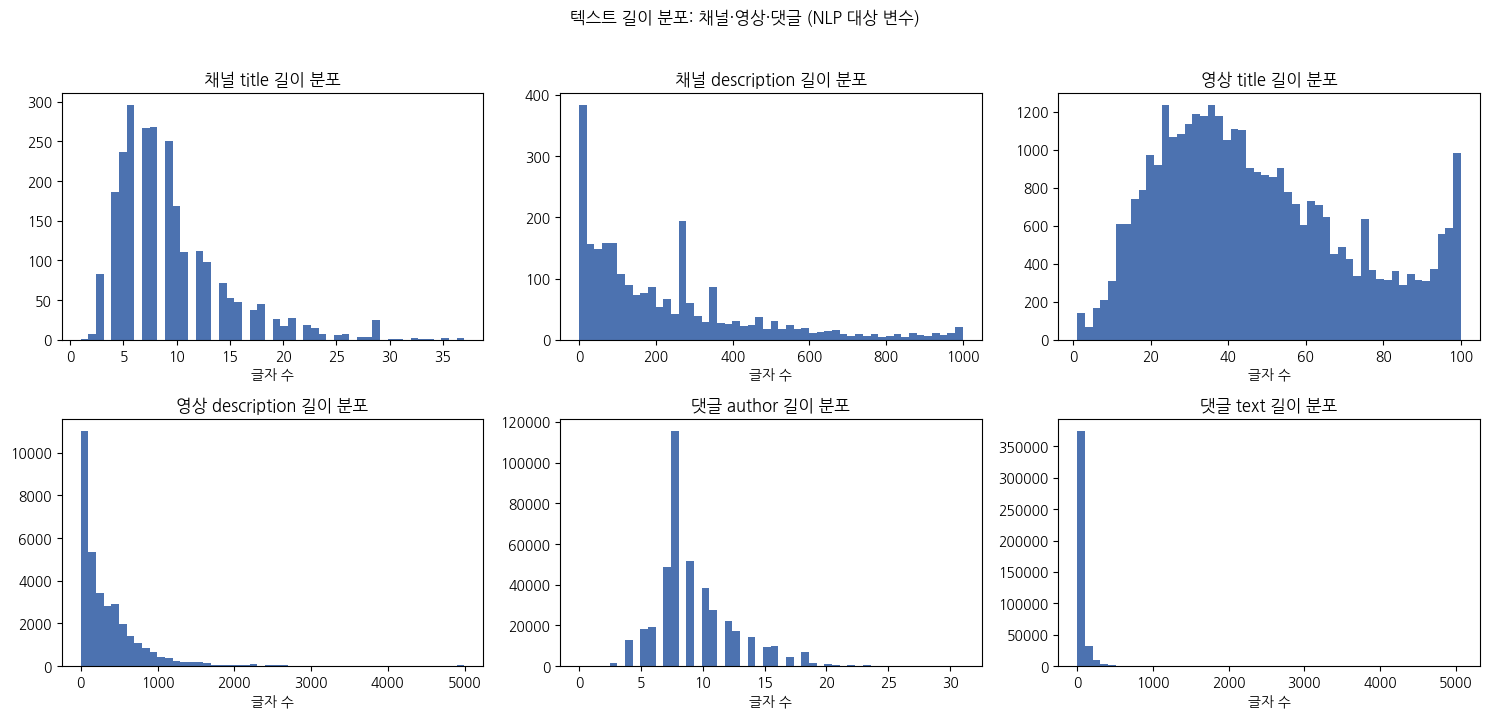

In [16]:
def len_stat(s):
    return s.fillna('').astype(str).str.strip().str.len()  # strip 기준 → 길이0 = 결측분석 빈값과 일치

txt_cols = {
    '채널 title':       df_channels['title'],
    '채널 description': df_channels['description'],
    '영상 title':       df_videos['title'],
    '영상 description': df_videos['description'],
    '댓글 author':      df_comments['author'],
    '댓글 text':        df_comments['text'],
}
lens = {k: len_stat(v) for k, v in txt_cols.items()}

for k, L in lens.items():
    z = int((L == 0).sum())
    print(f'{k:16s} 최소 {L.min():>2d} / 중앙 {L.median():>5.0f} / 최대 {L.max():>5d} / 길이0(빈값) {z}개({z/len(L)*100:.1f}%)')
print(f"댓글 text 고유값(중복 제거): {df_comments['text'].fillna('').astype(str).str.strip().nunique():,}개 / 전체 {len(df_comments):,} → 중복 다수")

fig, ax = plt.subplots(2, 3, figsize=(15, 7))
for a, (k, L) in zip(ax.ravel(), lens.items()):
    a.hist(L, bins=50, color='#4c72b0')
    a.set_title(f'{k} 길이 분포'); a.set_xlabel('글자 수')
fig.suptitle('텍스트 길이 분포: 채널·영상·댓글 (NLP 대상 변수)', y=1.02)
plt.tight_layout(); plt.show()


##### 3-2-8. 댓글 행동 패턴 - 행동 Attributes
**목적**
댓글 테이블(423,522행)은 이 프로젝트에서 가장 큰 신호원. 3-2-7은 댓글 *길이*만 봤지만, 리딩방·작전 채널의 진짜 흔적은 행동에 있다.
- **소수가 도배**: 적은 수의 작성자(봇·바람잡이)가 댓글을 반복.
- **같은 문구 복붙**: 동일한 텍스트가 여러 번 등장.
- **관리형 토론**: 대댓글이 비정상적으로 많은 구조.

댓글을 채널 단위로 묶어 이 세 패턴을 수치화 → H1(규제어 없는 행동 feature)·H2(군집)에 직접 입력.

**방법**
채널마다 세 지표를 계산.

| 지표 | 정의 | 읽는 법 |
|---|---|---|
| `author_uniq` | 고유 작성자수 / 댓글수 | 낮을수록 소수가 도배 |
| `text_uniq` | 고유 텍스트수 / 댓글수 | 낮을수록 같은 문구 복붙 |
| `reply_rate` | 대댓글수 / 댓글수 | 높을수록 관리형 토론 의심 |

비율의 분모(댓글수)가 너무 작으면 값이 불안정 → **댓글 30개 이상인 채널 604개**만 대상.

**결과** (댓글 30+ 채널 604개)

| 지표 | 중앙값 | 5% 분위 | 최소 | 해석 |
|---|---|---|---|---|
| `author_uniq` | 0.49 | 0.16 | **0.008** | 최소 = 댓글 2,602개를 작성자 ~20명이 작성 = 극단 도배 채널 |
| `text_uniq` | 0.94 | 0.47 | 0.09 | 대체로 다양, 하위 5%는 절반 이상 복붙 |
| `reply_rate` | 0.26 | — | 0 | 전체 대댓글 28.1%, 일부 채널은 66.7%까지 = 관리형 토론방 의심 |

- 같은 텍스트 최다 반복: `감사합니다` **8,481회** 등 정형 응원구 도배 존재.

**민감도** — 임계값 30이 결론을 좌우하나?
댓글 30개 기준은 통계 관행(n≥30)에서 빌려온 자의적 선택. 그래서 임계값을 5~100으로 바꿔가며 중앙 결론이 흔들리는지 확인.

| 댓글 최소 | 채널수 | `author_uniq` 중앙 | `text_uniq` 중앙 | `reply_rate` 중앙 | `author_uniq` p5(도배 꼬리) |
|---|---|---|---|---|---|
| 5 | 1,185 | 0.448 | 0.939 | 0.167 | 0.091 |
| 10 | 965 | 0.447 | 0.933 | 0.192 | 0.090 |
| 20 | 733 | 0.464 | 0.929 | 0.239 | 0.125 |
| **30 (채택)** | **604** | **0.488** | **0.935** | **0.260** | **0.159** |
| 50 | 494 | 0.496 | 0.936 | 0.270 | 0.157 |
| 100 | 380 | 0.507 | 0.937 | 0.272 | 0.163 |

- `author_uniq`·`text_uniq` 중앙값은 임계 5~100 내내 거의 그대로 → 핵심 결론은 임계값에 둔감(robust).
- 변하는 건 `reply_rate`와 꼬리(p5)뿐 → 임계값의 실제 역할은 소형 채널의 비율 노이즈를 걸러내는 것.

**결론**
- `author_uniq`(작성자 고유율): 소수 도배 = 봇·바람잡이의 직접 지표. 극단 저값(0.008) 채널은 작전 강한 의심 → H1·H2 핵심 feature. anomaly=target이라 삭제하지 않고 플래그로 보존(4-3).
- `text_uniq`(텍스트 고유율): 복붙 지표. 단 정형 응원구(`감사합니다`)는 정상 채널도 쓰므로 단독으론 약함 → 길이·작성자 집중과 교차 확인.
- `reply_rate`(대댓글 비율): 토론 활성도. 과도하면 관리형 방 신호 후보 → `is_reply`(3-1-3) 채널 집계로 확정.
- 임계값 30: 위 민감도표대로 중앙 결론이 둔감하므로 자의적이어도 선택은 정당. 다만 댓글 보유 1,575채널 중 604개만 남아 댓글 많은 인기 채널로 쏠리는 선택편향은 남음 → 군집·검정 단계에서 일반화 한계 명시.


댓글 30개 이상 채널 604개 / 댓글 보유 채널 1575개


,author_uniq,text_uniq,reply_rate
count,604.000,604.000,604.000
mean,0.502,0.859,0.268
std,0.216,0.181,0.177
min,0.008,0.088,0.000
5%,0.159,0.471,0.005
25%,0.336,0.799,0.112
50%,0.488,0.935,0.260
75%,0.673,0.984,0.415
max,1.000,1.000,0.667


전체 대댓글 비율 28.1%
동일 텍스트 최다 반복 top5:


text
감사합니다      8481
감사합니다.     2058
상수         1795
알림신청합니다    1390
❤          1206
Name: count, dtype: int64

[임계값 민감도]  (author_uniq·text_uniq 중앙이 임계에 둔감 = 결론 robust)
 thr   채널수  author_uniq중앙   text_uniq중앙   reply중앙  author_p5
   5  1185          0.448         0.939     0.167      0.091
  10   965          0.447         0.933     0.192      0.090
  20   733          0.464         0.929     0.239      0.125
  30   604          0.488         0.935     0.260      0.159
  50   494          0.496         0.936     0.270      0.157
 100   380          0.507         0.937     0.272      0.163


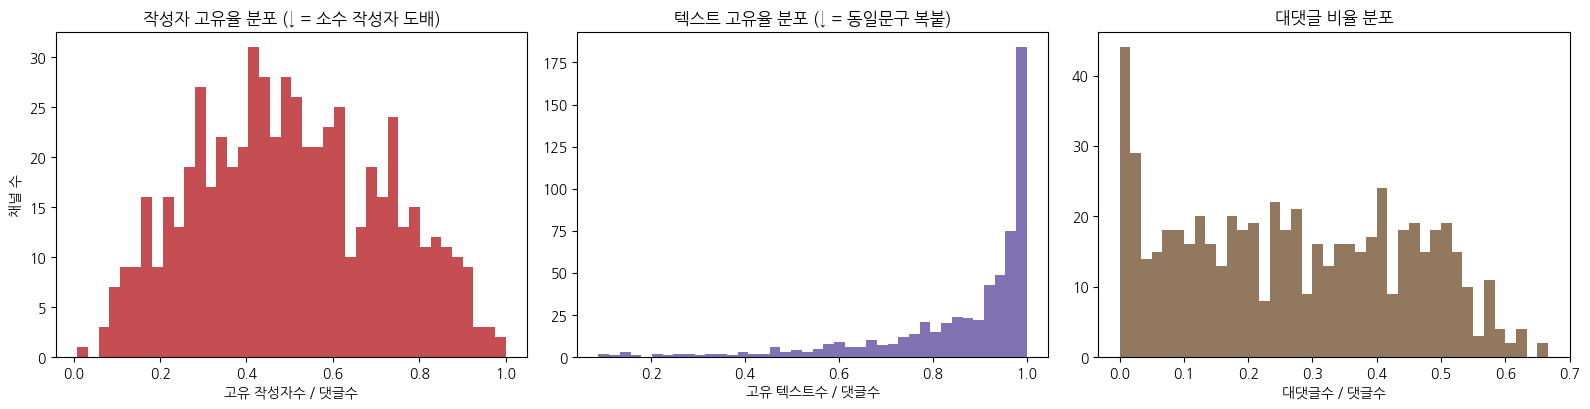

In [17]:
# 댓글 단위(423,522) → 채널 단위 행동 패턴 집계
g = df_comments.groupby('channel_id')
cmt_n = g.size()
beh = pd.DataFrame({
    'comment_n'   : cmt_n,
    'author_uniq' : g['author'].nunique() / cmt_n,   # 작성자 고유율 ↓ = 소수 도배
    'text_uniq'   : g['text'].nunique() / cmt_n,      # 텍스트 고유율 ↓ = 복붙 도배
    'reply_rate'  : df_comments['parent_id'].notna().groupby(df_comments['channel_id']).mean(),  # 대댓글 비율
})
beh_s = beh[beh['comment_n'] >= 30]   # 비율 분모 안정: 댓글 30개 이상 채널만
print(f'댓글 30개 이상 채널 {len(beh_s)}개 / 댓글 보유 채널 {len(beh)}개')
display(beh_s[['author_uniq','text_uniq','reply_rate']].describe(percentiles=[.05,.25,.5,.75]).round(3))
print(f'전체 대댓글 비율 {df_comments["parent_id"].notna().mean()*100:.1f}%')
print('동일 텍스트 최다 반복 top5:'); print(df_comments['text'].value_counts().head(5))

# 임계값 민감도: 댓글 최소 기준 30은 자의적 → 바꿔도 중앙 결론 안 흔들리는지(robust) 확인
print('\n[임계값 민감도]  (author_uniq·text_uniq 중앙이 임계에 둔감 = 결론 robust)')
print(f'{"thr":>4} {"채널수":>5} {"author_uniq중앙":>14} {"text_uniq중앙":>13} {"reply중앙":>9} {"author_p5":>10}')
for t in [5, 10, 20, 30, 50, 100]:
    s = beh[beh['comment_n'] >= t]
    print(f'{t:>4} {len(s):>5} {s["author_uniq"].median():>14.3f} {s["text_uniq"].median():>13.3f} '
          f'{s["reply_rate"].median():>9.3f} {s["author_uniq"].quantile(.05):>10.3f}')

fig, ax = plt.subplots(1, 3, figsize=(16, 4.2))
ax[0].hist(beh_s['author_uniq'], bins=40, color='#c44e52')
ax[0].set_title('작성자 고유율 분포 (↓ = 소수 작성자 도배)'); ax[0].set_xlabel('고유 작성자수 / 댓글수'); ax[0].set_ylabel('채널 수')
ax[1].hist(beh_s['text_uniq'], bins=40, color='#8172b3')
ax[1].set_title('텍스트 고유율 분포 (↓ = 동일문구 복붙)'); ax[1].set_xlabel('고유 텍스트수 / 댓글수')
ax[2].hist(beh_s['reply_rate'], bins=40, color='#937860')
ax[2].set_title('대댓글 비율 분포'); ax[2].set_xlabel('대댓글수 / 댓글수')
plt.tight_layout(); plt.show()


##### 3-2-9. 연락처·외부유도 형식 - 형식 regex Attributes
**목적**
불법 리딩방의 핵심 수법 = 시청자를 유튜브 밖 유료방(카톡·텔레그램·밴드)으로 빼내는 것. 연락처가 노출되는 자리는 세 곳이다.
- 영상 설명(description)
- 채널 설명(description)
- **채널 주인이 자기 영상에 직접 단 댓글**

규제어(급등주·리딩방 등)는 라벨 근거라 feature로 쓰면 순환(leakage). 하지만 URL·연락처는 *의미*가 아니라 *형식*이라 정규식으로 뽑아도 leakage가 아님(regex≠ML 원칙) → feature 허용. 여기선 형식 플래그만 단변량으로 추출.

**방법**
다섯 형식 정규식을 세 텍스트 소스에 적용.

| 플래그 | 무엇을 잡나 |
|---|---|
| `has_url` | http/www 링크 |
| `has_kakao` | 카톡·오픈채팅 |
| `has_phone` | 01X-XXXX-XXXX 전화번호 |
| `has_telegram` | t.me·텔레그램 |
| `has_band` | 네이버 밴드 |

- **소유자 댓글** 식별: 댓글 작성자 핸들(`@xxx`)이 채널 핸들(`custom_url`)과 일치하는 댓글만 추림(53,157개·1,238채널). 시청자가 단 URL은 채널 행동이 아니라 제외.
- `has_contact` = 위 다섯 중 하나라도 매칭.
- `has_email`(주소@도메인)은 유료방 유도가 아니라 광고·제휴 문의 창구라, `has_contact`에서 빼고 따로 집계(분리 근거는 결론).
- 규제 키워드는 일절 매칭 안 함(leakage 차단).

**결과**

| 플래그 | 영상 desc(34,162) | 채널 desc(2,508) | 소유자 댓글(53,157) |
|---|---|---|---|
| `has_url` | 30.1% | 11.4% | 17.7% |
| `has_kakao` | 16.6% | 20.6% | 7.8% |
| `has_phone` | 5.7% | 2.5% | 0.9% |
| `has_telegram` | 6.9% | 2.8% | 1.7% |
| `has_band` | 1.0% | 0.5% | 0.3% |
| **`has_contact`(유도 any)** | **42.7%** | **30.2%** | **24.0%** |
| `has_email`(대조축) | 6.8% | 11.8% | 0.6% |

- 채널 단위(세 소스 중 하나라도): **any-contact 64.5%**(소유자 댓글 추가로 60.0%→64.5%, +112채널), any-email 15.0%

**결론**

*유료방 유도 플래그 = H1 핵심 feature*
- 카톡·텔레그램·전화·밴드(`has_kakao`·`has_telegram`·`has_phone`·`has_band`)는 시청자를 유튜브 밖 유료방으로 데려가는 흔적 → 리딩방 대표 행동 신호. 규제어 없이 행동·구조만으로 판별한다는 H1 가설과 맞음.
- 채널 주인이 자기 영상 댓글에 링크를 남기는 경우도 포착(소유자 댓글의 24%에 연락처). 설명만 보면 놓치는 유도를 추가로 잡음 → 채널 단위 60.0%→64.5%(+112채널).

*`has_contact`는 EDA 요약용, 모델 입력 아님*
- 다섯 플래그를 OR로 합친 파생값이라 원본 플래그들과 정보가 겹침(다중공선성) → 선형·PCA·군집에서 계수를 왜곡. 모델엔 개별 플래그만 투입하고, `has_contact`는 전체 그림을 요약하는 용도로만 사용.

*`has_email`을 `has_contact`에서 뺀 이유*
이메일은 유료방으로 유도하는 수단이 아니라 광고·제휴 문의를 받는 정상 연락 창구이기 때문. 데이터로도 확인된다.
- 유도 흔적이 **없는** 채널의 이메일 표기율 16.1% > **있는** 채널 13.7% → 유도하는 채널이 오히려 이메일을 덜 적음.
- 이메일 표기와 유도 신호의 상관계수(phi)는 −0.03(유도 전체)·−0.05(카톡)로 거의 0 → 둘은 사실상 무관.
- 이메일을 적은 채널 중 58%는 유도 흔적이 아예 없음 → 대부분 평범한 사업 문의용.
- 따라서 `has_contact`에 합치면 진짜 유도 신호에 정상 채널이 섞여 희석됨 → 분리. 이메일은 단독으론 리딩방 판별력이 약하고, 다른 유도·행동 feature와 함께 볼 때 '정상 사업자 vs 유료방 유도'를 구분하는 보조 지표로만 사용.

*기타*
- 모든 플래그는 형식 정규식이라 leakage와 무관(규제 의미 단어가 아니라 URL·연락처의 *형식*만 봄). 규제 키워드 같은 의미 단어 분석은 임베딩으로 따로 다룸(4장·모델링).
- 선택편향: 모집단이 주식 키워드로 검색된 채널이라 일반 유튜브보다 연락처 노출률이 높게 나올 수 있음(해석 시 주의).


소유자 본인 댓글 53,157개 / 전체 423,522 (12.6%), 1,238개 채널



[연락처·외부유도 형식 플래그]
              영상 desc %  채널 desc %  소유자 댓글 %
has_url            30.1       11.4      17.7
has_kakao          16.6       20.6       7.8
has_phone           5.7        2.5       0.9
has_telegram        6.9        2.8       1.7
has_band            1.0        0.5       0.3
has_contact        42.7       30.2      24.0
has_email           6.8       11.8       0.6

채널 단위 any-contact(유도, 채널·영상 desc + 소유자 댓글): 64.5%  (채널 2,508)
채널 단위 any-email(대조축, 외부유도 아님): 15.0%
[email 분리 근거] 유도 흔적 없는 채널 email률 16.1% > 있는 채널 13.7% / phi(email,lure)=-0.034 → email은 외부유도 마커 아님 → has_contact 제외 타당
[email 분리 근거] 이메일 표기 채널 중 유도 흔적 없는 비율 58%
채널 단위 연락처 플래그 생성: ['has_url', 'has_kakao', 'has_phone', 'has_telegram', 'has_band', 'has_email']


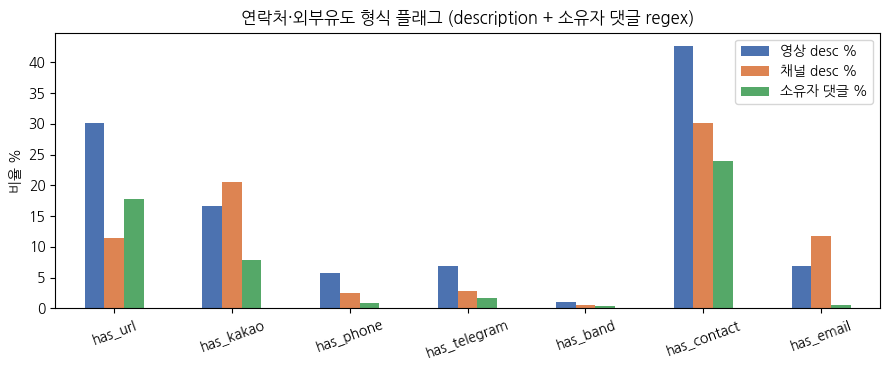

In [18]:
# 형식 regex(연락처·외부유도) — 규제 의미어는 일절 매칭 안 함(leakage 차단, 형식만)
contact_pats = {
    'has_url'     : r'https?://|www\.',
    'has_kakao'   : r'카카오|카톡|오픈\s*채팅|open\.kakao|kakao',
    'has_phone'   : r'01[016789][-.\s]?\d{3,4}[-.\s]?\d{4}',
    'has_telegram': r'텔레그램|telegram|t\.me',
    'has_band'    : r'네이버\s*밴드|band\.us',
}
EMAIL_PAT = r'[A-Za-z0-9._%+-]+@[A-Za-z0-9.-]+\.[A-Za-z]{2,}'  # 이메일=광고·비즈니스 문의(중립) → has_contact 제외, 별도 대조축
def contact_flags(text):
    s = text.fillna('').astype(str)
    f = pd.DataFrame({k: s.str.contains(p, case=False, regex=True) for k, p in contact_pats.items()})
    f['has_contact'] = f.any(axis=1)            # 외부 유료방 유도 5종 OR(이메일 제외) — EDA 요약 지표, 모델 feature엔 미투입(개별 플래그만)
    f['has_email']   = s.str.contains(EMAIL_PAT, regex=True)
    return f

# 소유자 본인 댓글: 댓글 author 핸들(@xxx)이 채널 핸들(custom_url)과 일치 = 채널 주인이 자기 영상에 직접 단 댓글(링크 홍보). 시청자 댓글의 URL은 채널 행동 아님 → 제외
ch_handle = df_channels[['channel_id', 'custom_url']].copy()
ch_handle['handle'] = ch_handle['custom_url'].fillna('').astype(str).str.lstrip('@').str.lower()
cmt = df_comments.merge(ch_handle[['channel_id', 'handle']], on='channel_id', how='left')
cmt['author_handle'] = cmt['author'].fillna('').astype(str).str.lstrip('@').str.lower()
owner_cmt = cmt[(cmt['handle'] != '') & (cmt['author_handle'] == cmt['handle'])]
print(f'소유자 본인 댓글 {len(owner_cmt):,}개 / 전체 {len(cmt):,} ({len(owner_cmt)/len(cmt)*100:.1f}%), {owner_cmt["channel_id"].nunique():,}개 채널')

vflag = contact_flags(df_videos['description'])
cflag = contact_flags(df_channels['description'])
oflag = contact_flags(owner_cmt['text'])
tbl = pd.DataFrame({
    '영상 desc %'  : (vflag.mean()*100).round(1),
    '채널 desc %'  : (cflag.mean()*100).round(1),
    '소유자 댓글 %': (oflag.mean()*100).round(1),
})
print('\n[연락처·외부유도 형식 플래그]'); print(tbl)

# 채널 단위: 채널 desc OR 영상 desc OR 소유자 댓글 중 하나라도
def channel_any(col):
    parts = [
        cflag[col].set_axis(df_channels['channel_id']),
        vflag.assign(channel_id=df_videos['channel_id']).groupby('channel_id')[col].any(),
        oflag.assign(channel_id=owner_cmt['channel_id']).groupby('channel_id')[col].any(),
    ]
    return pd.concat(parts, axis=1).reindex(df_channels['channel_id']).fillna(False).any(axis=1)

chan_any   = channel_any('has_contact')
chan_email = channel_any('has_email')
print(f'\n채널 단위 any-contact(유도, 채널·영상 desc + 소유자 댓글): {chan_any.mean()*100:.1f}%  (채널 {len(chan_any):,})')
print(f'채널 단위 any-email(대조축, 외부유도 아님): {chan_email.mean()*100:.1f}%')

# email를 has_contact에서 빼는 실증 근거: 유료방 유도 흔적 보유 vs 미보유 email률 + 상관
lure_cols = ['has_kakao', 'has_phone', 'has_telegram', 'has_band']
def channel_lure():
    parts = [
        cflag[lure_cols].set_axis(df_channels['channel_id']).any(axis=1),
        vflag.assign(channel_id=df_videos['channel_id']).groupby('channel_id')[lure_cols].any().any(axis=1),
        oflag.assign(channel_id=owner_cmt['channel_id']).groupby('channel_id')[lure_cols].any().any(axis=1),
    ]
    return pd.concat(parts, axis=1).reindex(df_channels['channel_id']).fillna(False).any(axis=1)
chan_lure = channel_lure()
em_by_lure = chan_email.groupby(chan_lure).mean() * 100
phi = np.corrcoef(chan_email.astype(int), chan_lure.astype(int))[0, 1]
print(f'[email 분리 근거] 유도 흔적 없는 채널 email률 {em_by_lure.get(False,0):.1f}% > 있는 채널 {em_by_lure.get(True,0):.1f}% '
      f'/ phi(email,lure)={phi:.3f} → email은 외부유도 마커 아님 → has_contact 제외 타당')
print(f'[email 분리 근거] 이메일 표기 채널 중 유도 흔적 없는 비율 {((chan_email & ~chan_lure).sum()/chan_email.sum())*100:.0f}%')

# 채널 단위 개별 플래그 → 4-4 channel_features 전달(regex 1회만). 모델엔 개별 플래그·has_email만, has_contact(OR 합성)는 제외
chan_flags = pd.DataFrame({c: channel_any(c) for c in list(contact_pats) + ['has_email']})
chan_flags.index.name = 'channel_id'
print(f'채널 단위 연락처 플래그 생성: {list(chan_flags.columns)}')

fig, ax = plt.subplots(figsize=(9, 3.8))
tbl.plot(kind='bar', ax=ax, color=['#4c72b0', '#dd8452', '#55a868'])
ax.set_title('연락처·외부유도 형식 플래그 (description + 소유자 댓글 regex)'); ax.set_ylabel('비율 %')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout(); plt.show()

#### 3-3. Exploring Patterns
3-2에서는 변수 *하나씩*(단변량) 봤다면, 3-3은 변수 *사이*의 관계를 파악

속성 *간* 관계·추세·구조, 그리고 규칙에서 벗어나는 **이상(anomaly)** 단서를 탐색.

**3축**

| 축 | 보는 것 | 주의 |
|---|---|---|
| 3-3-1 공분산 | 동반 변화의 방향 | 단위 민감 → 부호만, 크기 비교 X |
| 3-3-2 상관 | 표준화(−1~+1) 선형 강도 | 상관 낮음 ≠ 무관계(비선형) → Spearman 병행 |
| 3-3-3 규칙성 | 추세·규칙 + 이탈 | 이탈 = 작전성·봇 anomaly 후보 |

##### 3-3-1. Covariance (공분산)
**목적**: 두 변수가 **같은 방향으로 움직이는지(동반 변화)** 부호로 확인. 공분산은 **단위에 민감**(단위만 커져도 값 폭증)이라 절대 크기는 무의미 → **부호만** 읽고, 세기 비교는 표준화한 상관(3-3-2)으로 넘김.

**결과** (videos 4지표: 조회·좋아요·댓글·길이)

| 변수 | 표준편차 |
|---|---|
| `view_count` | 108,392 |
| `duration_seconds` | 4,276 |
| `like_count` | 969 |
| `comment_count` | 97 |

- 공분산 행렬 **모든 쌍 부호 +** = 한 지표가 크면 다른 지표도 큼(동반 증가)
- 단 `view_count` std가 압도적(10만↑ vs 댓글 97) → 공분산 절대크기를 혼자 끎

**결론**
- 부호 전부 양(+) → 규모·참여 지표는 **같이 커지는 구조**(3-2-2 우편향·3-2-3 규모종속과 일관). 방향은 확인됐으나 **세기는 비교 불가**(단위가 값 지배).
- 다음 단계 = 단위 약분한 **표준화 상관(3-3-2)** 으로 관계 세기 측정. 공분산은 부호 확인 역할로 종료.


In [19]:
vid_num4 = ['view_count','like_count','comment_count','duration_seconds']

# 공분산 행렬: 부호(방향)만 의미, 절대크기는 스케일에 지배됨(단위 민감)
print('[videos] 공분산 행렬 — 단위 민감 (절대크기 비교 X, 부호만)')
display(df_videos[vid_num4].cov())

# 같은 데이터의 표준편차: view_count가 압도적으로 커서 공분산 크기를 끈다는 근거
print('각 변수 표준편차 (스케일 차이 확인):')
display(df_videos[vid_num4].std().round(1).to_frame('std'))

[videos] 공분산 행렬 — 단위 민감 (절대크기 비교 X, 부호만)


,view_count,like_count,comment_count,duration_seconds
view_count,1.174882e+10,3.616406e+07,2.523045e+06,9.602484e+06
like_count,3.616406e+07,9.387374e+05,6.937257e+04,2.221629e+05
comment_count,2.523045e+06,6.937257e+04,9.367940e+03,1.351213e+03
duration_seconds,9.602484e+06,2.221629e+05,1.351213e+03,1.828302e+07


각 변수 표준편차 (스케일 차이 확인):


,std
view_count,108392.0
like_count,968.9
comment_count,96.8
duration_seconds,4275.9


##### 3-3-2. Correlation (상관관계)
**목적**: 공분산(3-3-1)이 부호만 줬으니 **표준화(−1~+1)** 해 관계 **세기**를 측정. 우편향 보정 위해 **log1p 후 Pearson**(선형), 비선형·극단치 대비 **Spearman 병행**(순위 기반, 3-2-6 근거와 동일). 목적 = 묶이는 변수군(다중공선성) 식별 → feature 설계·PCA(H2) 판단.

**방법**
- Pearson은 선형·정규 가정 → raw는 극단치에 끌림 → `log1p` 후 봄(3-2-2 로그 근거와 일관)
- "상관 낮음 ≠ 무관계"(비선형) → Spearman(순위 기반, 변환 불변)로 단조 관계까지 포착

**결과** (Spearman 기준)

| videos 쌍 | ρ | channels 쌍 | ρ |
|---|---|---|---|
| 조회–좋아요 | 0.78 | 구독–영상수 | 0.82 |
| 좋아요–댓글 | 0.61 | 구독–총조회 | 0.88 |
| 조회–댓글 | 0.53 | 영상수–총조회 | 0.91 |
| 조회–길이 | 0.18 | — | — |

- comments(댓글 단위, 수치 = `like_count`·`text` 길이 2개뿐 → 단일 쌍): **길이–좋아요 ρ = 0.15**(약한 양)

**결론**
- 영상: 조회·좋아요·댓글 강한 양의 단조(0.53~0.78), 길이는 약함(0.18) → **참여 3종 묶음**. 단 절대수는 규모종속이라 모델 입력은 3-2-3 **참여율**(조회 정규화)로 — 상관표가 "조회가 좋아요·댓글을 끈다"는 3-2-3 전제를 정량 확인.
- 채널: 규모 3변수 매우 높은 상관(0.82~0.91) → **다중공선성**(그대로 넣으면 중복) → **PCA 차원축소(H2)** 근거 확보.
- 댓글: 길이–좋아요 ρ=0.15 = 거의 독립 → 길이는 단독 약 feature, text는 **임베딩(의미)이 본선**(3-2-7 일관). 도배·작성자 집중(3-2-8)은 이 수치쌍이 아닌 채널 집계 행동지표라 상관행렬과 별개 축.


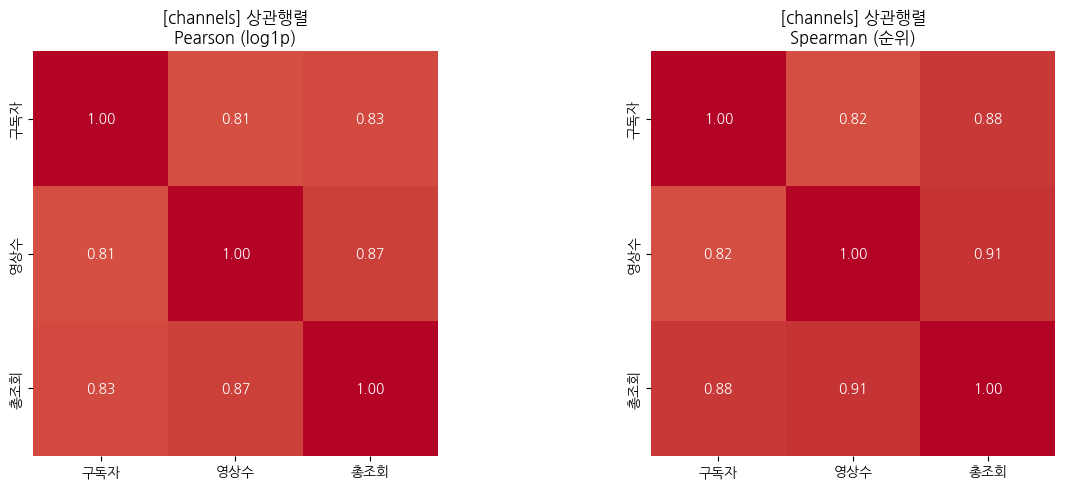

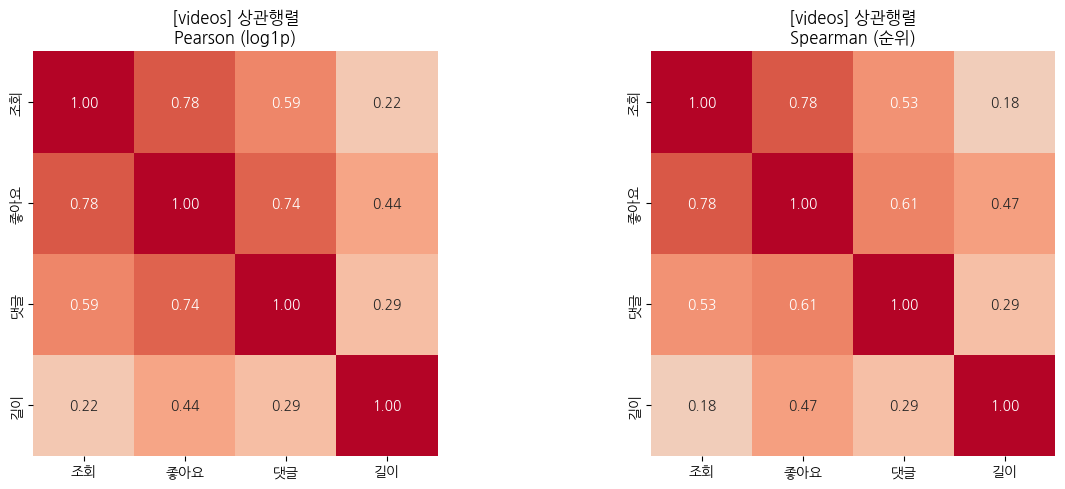

[comments] 길이-좋아요  Spearman 0.15 / Pearson(log1p) 0.15


In [20]:
def corr_pair(df, cols, title, labels):
    sub = df[cols].clip(lower=0)
    pear = np.log1p(sub).corr(method='pearson')   # 선형(우편향 보정 위해 log1p)
    spear = sub.corr(method='spearman')           # 단조(순위, 변환 불변)
    fig, ax = plt.subplots(1, 2, figsize=(13, 5))
    for a, m, name in [(ax[0], pear, 'Pearson (log1p)'), (ax[1], spear, 'Spearman (순위)')]:
        sns.heatmap(m, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                    square=True, xticklabels=labels, yticklabels=labels,
                    cbar=False, ax=a)
        a.set_title(f'{title}\n{name}')
    plt.tight_layout(); plt.show()

# 채널 단위
corr_pair(df_channels, ['subscriber_count','video_count','view_count'],
          '[channels] 상관행렬', ['구독자','영상수','총조회'])
# 영상 단위
corr_pair(df_videos, vid_num4, '[videos] 상관행렬',
          ['조회','좋아요','댓글','길이'])

# 댓글 단위 (수치 = like_count·text 길이 2개뿐 → 쌍 상관만)
ctext_len = df_comments['text'].fillna('').astype(str).str.strip().str.len()
clike = df_comments['like_count'].clip(lower=0)
csp = ctext_len.corr(clike, method='spearman')
cpe = np.log1p(ctext_len).corr(np.log1p(clike), method='pearson')
print(f'[comments] 길이-좋아요  Spearman {csp:.2f} / Pearson(log1p) {cpe:.2f}')


##### 3-3-3. Regularity (규칙성)
**목적**: 데이터의 **추세·규칙**을 잡고 거기서 **벗어나는 이탈 = anomaly 후보**를 발굴(→ 4-3 Anomaly 연결). 본 프로젝트 목표 직결 — 정상 채널은 규모-참여 규칙을 따르고, 작전성·유령은 규칙선을 이탈.

**방법** (보는 규칙 2가지)

| 규칙 | 내용 | anomaly 신호 |
|---|---|---|
| 시간 추세 | 채널 개설 연도별 신규 유입(3-2-5) | 최근 급증기 ↔ 리딩방 신생 가설 |
| 규모–참여 | 구독자↑→총조회↑ (Spearman 0.88, 3-3-2) | 규칙선 크게 이탈 = 작전/유령 후보 |

**결과**: 구독자~총조회 로그-로그 규칙선에서 |잔차|>2.5σ 이탈 = **54개(2.7%)**

**결론**
- 시간 추세 = 3-2-5 개설 급증(2026년 37%) 재확인 → 신생 채널군이 리딩방 가설 후보.
- 규모-참여 이탈 54개 = 구독 대비 조회 과다/과소 → **작전성·매수·유령 anomaly 후보**. anomaly=target이라 삭제 X → 4-3에서 flag·라벨링 단서로 보존.
- Patterns 종합: 변수들이 강하게 묶이는(상관 0.8+) **규칙적 구조** 위에서 소수 이탈만 추출 = 이상 탐지 출발점. 이 이탈군이 H1 라벨·H2 군집 분리의 1차 후보.


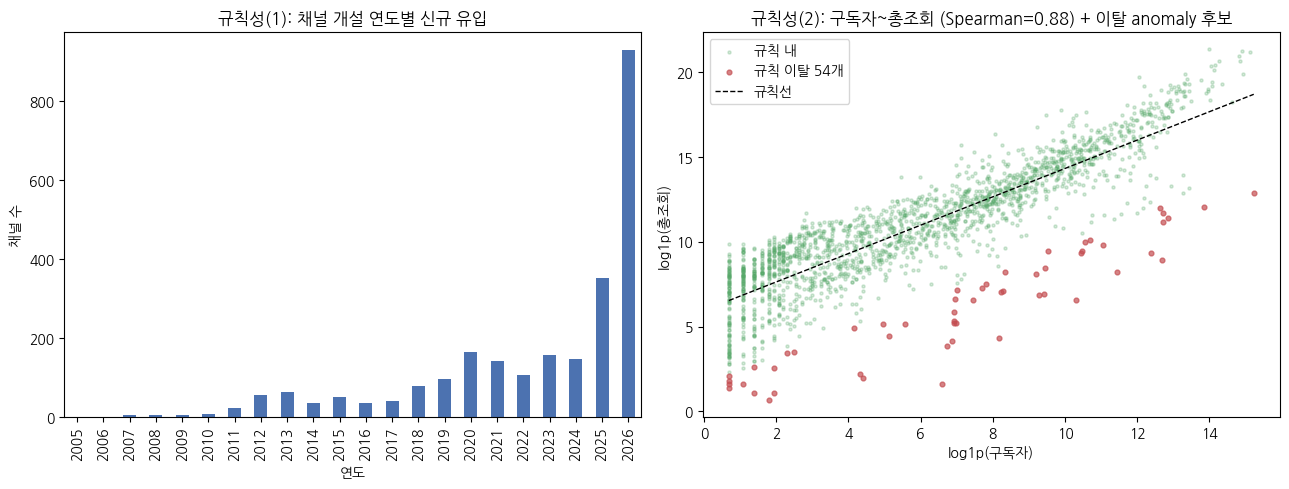

규모-참여 규칙 이탈 채널: 54개 (2.7%) → 작전/유령 anomaly 후보, 4-3 Anomaly에서 검토


In [21]:
m = (df_channels['subscriber_count'] > 0) & (df_channels['view_count'] > 0)
ch = df_channels[m].copy()
x, y = np.log1p(ch['subscriber_count']), np.log1p(ch['view_count'])
rho = ch[['subscriber_count','view_count']].corr(method='spearman').iloc[0,1]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
# (1) 시간 추세: 개설 연도별 신규 채널
yr = pd.to_datetime(df_channels['published_at'], format='ISO8601', utc=True).dt.year
yr.value_counts().sort_index().plot(kind='bar', ax=ax[0], color='#4c72b0')
ax[0].set_title('규칙성(1): 채널 개설 연도별 신규 유입'); ax[0].set_xlabel('연도'); ax[0].set_ylabel('채널 수')

# (2) 규모-참여 규칙선 + 이탈(anomaly 후보)
coef = np.polyfit(x, y, 1)                       # 규칙선(로그-로그 추세)
resid = y - np.polyval(coef, x)                  # 규칙에서의 이탈
thr = 2.5 * resid.std()                          # 큰 이탈 임계
out = resid.abs() > thr
ax[1].scatter(x[~out], y[~out], s=5, alpha=0.25, color='#55a868', label='규칙 내')
ax[1].scatter(x[out],  y[out],  s=12, alpha=0.7, color='#c44e52', label=f'규칙 이탈 {int(out.sum())}개')
ax[1].plot(np.sort(x), np.polyval(coef, np.sort(x)), 'k--', lw=1, label='규칙선')
ax[1].set_xlabel('log1p(구독자)'); ax[1].set_ylabel('log1p(총조회)')
ax[1].set_title(f'규칙성(2): 구독자~총조회 (Spearman={rho:.2f}) + 이탈 anomaly 후보')
ax[1].legend()
plt.tight_layout(); plt.show()

print(f'규모-참여 규칙 이탈 채널: {int(out.sum())}개 ({out.mean()*100:.1f}%) → 작전/유령 anomaly 후보, 4-3 Anomaly에서 검토')

##### 3-3-4. 댓글 시딩 패턴 - 첫 댓글까지 시간 (행동 timing 관계)
**목적**: 영상 게시 후 **첫 댓글까지 걸린 시간**(`first_comment − published`) 분포로 **시딩(seeding) 정황** 점검. 게시 직후 즉시 댓글 = 대기·동원 작성자(바람잡이·관리방) 의심. 두 timestamp(영상·댓글) 관계라 단변량(3-2) 아닌 패턴(3-3).

**결과** (댓글 달린 영상 15,618개)

| 지표 | 값 |
|---|---|
| 첫 댓글까지 중앙값 | **0.23시간(≈14분)** |
| 1시간 이내 | **65.2%** |
| 24시간 이내 | 76.8% |
| 음수(영상 게시 전 댓글=수집 시각 불일치) | 1,931개(12.4%) |

**결론**
- 첫 댓글 중앙 14분·1시간내 65% = **상당수 영상이 게시 직후 즉시 댓글** → 대기 작성자 동원(시딩) 정황. 3-2-8 작성자 집중(소수 도배)과 같은 작전 신호 축.
- anomaly=target → 즉시 시딩 영상·채널 삭제 X, **flag**(4-3). 채널 집계 `median_ttf`(첫댓글 중앙시간) = H1 행동 feature·H2 군집 후보.
- 음수 12.4% caveat: 영상 published_at보다 이른 댓글 timestamp = API 수집 시각 불일치(타임존·게시 전 비공개 등). 시딩 계산 시 음수 제외 → 양수만 중앙 0.43h·1시간내 60.3%로 결론 동일.


댓글 달린 영상 15,618개
첫 댓글까지 중앙 0.23h / 1시간내 65.2% / 24시간내 76.8%
음수(게시 전 댓글=수집 시각 불일치) 1,931개 (12.4%)


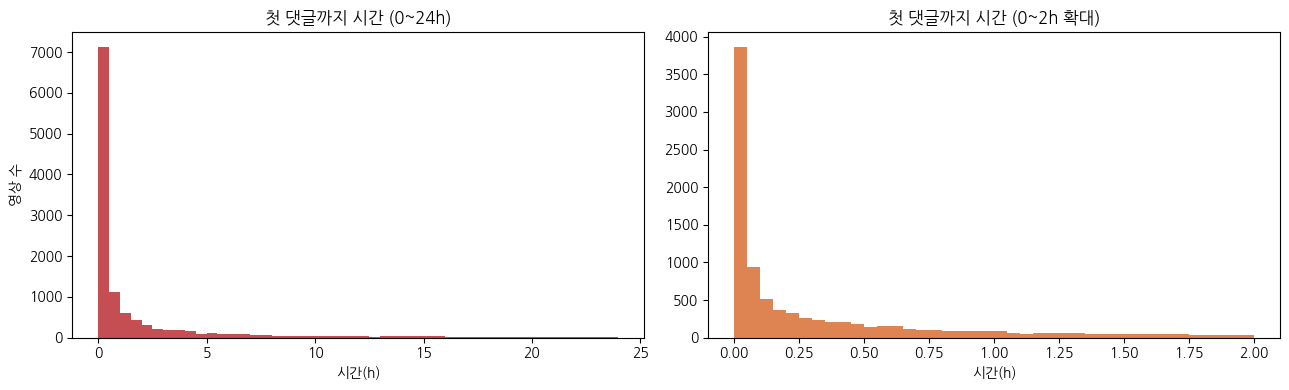

채널 단위 median_ttf 생성: 1,539개 채널 (양수 first-comment 기준)


In [22]:
# 첫 댓글까지 시간: 영상 게시 → 그 영상 첫 댓글 (두 timestamp 관계 = 3-3)
v_pub = pd.to_datetime(df_videos['published_at'],   format='ISO8601', utc=True)
c_pub = pd.to_datetime(df_comments['published_at'], format='ISO8601', utc=True)
first_c   = c_pub.groupby(df_comments['video_id']).min()
v_pub_map = v_pub.set_axis(df_videos['video_id'])           # tz 보존(.values 쓰면 tz 소실)
ttf = ((first_c - v_pub_map.reindex(first_c.index)).dt.total_seconds() / 3600).dropna()

print(f'댓글 달린 영상 {len(ttf):,}개')
print(f'첫 댓글까지 중앙 {ttf.median():.2f}h / 1시간내 {(ttf<=1).mean()*100:.1f}% / 24시간내 {ttf.between(0,24).mean()*100:.1f}%')
print(f'음수(게시 전 댓글=수집 시각 불일치) {int((ttf<0).sum()):,}개 ({(ttf<0).mean()*100:.1f}%)')

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].hist(ttf[ttf.between(0, 24)], bins=48, color='#c44e52')
ax[0].set_title('첫 댓글까지 시간 (0~24h)'); ax[0].set_xlabel('시간(h)'); ax[0].set_ylabel('영상 수')
ax[1].hist(ttf[ttf.between(0, 2)], bins=40, color='#dd8452')
ax[1].set_title('첫 댓글까지 시간 (0~2h 확대)'); ax[1].set_xlabel('시간(h)')
plt.tight_layout(); plt.show()

# 채널 집계 median_ttf(양수만) → 4-4 H1/H2 행동 feature 전달
_vid2ch = df_videos.set_index('video_id')['channel_id']
_ttf_pos = ttf[ttf >= 0]
chan_ttf = _ttf_pos.groupby(_vid2ch.reindex(_ttf_pos.index)).median().rename('med_ttf_hours')
print(f'채널 단위 median_ttf 생성: {chan_ttf.notna().sum():,}개 채널 (양수 first-comment 기준)')


### **4. Data Pre-processing**
**← 3장 연결**: 3-2·3-3에서 **진단**한 우편향·0-과잉·극단치·anomaly를 이제 **처리**(변환·flag·삭제)로 옮김.

원시 데이터를 분석에 맞게 정제. **4-1 Missing → 4-2 Outlier → 4-3 Anomaly → 4-4 조립** 순.

**지배 원칙 2가지**

| 원칙 | 내용 |
|---|---|
| ① 다운스트림 정렬 | H1 분류·H2 군집/PCA·H3 검정이 요구하는 입력 보존·생성: log1p 스케일 보정 / 참여비율 feature / 범주 이진화 |
| ② Retention(삭제 최소) | outlier·anomaly = 타깃 신호일 수 있음(리딩방·봇·유령) → 삭제 X, **변환(log)·플래그**. 수집 오류로 판명된 것만 삭제 |

> 가설: **H1** 리딩방 분류 / **H2** 작전성 군집 분리 / **H3** 의심군 참여율 평균차. 원본 DB(`youtube_channels.db`) 보존, 결과는 `data/processed/`에 별도 저장.

#### 4-1. Missing data processing
**목적**: 결측 유형(MCAR/MAR/MNAR)을 판단해 전략(Retention/Deletion/Imputation)을 고른다. `isnull()`은 0이지만 **빈 문자열이 실질 결측** → `NaN`으로 표준화한 뒤 처리.

**방법**: 빈 문자열을 `NaN`으로 바꿔 숨은 결측을 드러내고, 컬럼별 결측률·유형을 보고 전략을 정한다.

**결과 + 전략**

| 컬럼 | 결측률 | 유형 | 전략 | 논리 |
|---|---|---|---|---|
| `language` | 96.7% | MCAR(API 미제공) | **Deletion(열 삭제)** | 거의 전부 결측 → 정보 없음 |
| `country` | 44.9% | MAR | **Retention → `is_kr`** | KR/비KR 구분 의미, 빈값=비KR/미상 정보화 |
| `description` | 12.4%(ch)/10.4%(vd) | MNAR | **Retention + `has_description`** | 빈 설명 자체가 채널 특성(부실 신호) |
| `custom_url` | 1.6% | MNAR | **Retention** | 소수, title 보완용 |
| `parent_id` | 71.9% | **결측 아님(구조적)** | `is_reply` flag | 최상위 댓글은 정의상 부모 없음 |
| `like_count` | 0(0-과잉 48.6%) | **결측 아님(0-과잉)** | `has_like` flag | 3-2-1 결론 — 0/비0 분리 |

**결론**
- `language`만 열 삭제(거의 전부 결측). 나머지는 보존하며 정보화: `country`→`is_kr`, `description`→`has_description`, `parent_id`→`is_reply`, `like_count`→`has_like`(0/비0, 3-2-1).
- **Imputation(대치)은 쓰지 않는다**: 수치형 명시 결측 0 + 평균/중앙 대치는 강한 우편향을 왜곡, 범주형은 '미상'을 한 범주로 보존하는 편이 정보 손실이 적다.


In [23]:
# (1) 명시적 결측: isnull 기준 → parent_id 외 0
print('=== isnull (명시적 결측) ===')
print('channels:', df_channels.isnull().sum().sum(), '| videos:', df_videos.isnull().sum().sum(),
      '| comments(parent_id 제외):', df_comments.drop(columns=['parent_id']).isnull().sum().sum())

# (2) 숨은 결측: 문자열 컬럼의 빈 문자열('') 비율
def empty_ratio(df, cols):
    return pd.Series({c: (df[c].astype(str).str.strip() == '').mean() * 100 for c in cols}).round(1)

print('\n=== 숨은 결측: 빈 문자열 비율(%) ===')
print('[channels]'); print(empty_ratio(df_channels, ['description','custom_url','country','language']).to_string())
print('[videos]');   print(empty_ratio(df_videos, ['description']).to_string())

# (3) parent_id: 결측이 아니라 '최상위 댓글' 구조 → 비율만 확인
print(f"\n=== comments.parent_id: NaN={df_comments['parent_id'].isna().mean()*100:.1f}% (= 최상위 댓글, 결측 아님) ===")

=== isnull (명시적 결측) ===
channels: 0 | videos: 0 | comments(parent_id 제외): 0

=== 숨은 결측: 빈 문자열 비율(%) ===
[channels]
description    12.4
custom_url      1.6
country        44.9
language       96.7
[videos]
description    10.4

=== comments.parent_id: NaN=71.9% (= 최상위 댓글, 결측 아님) ===


In [24]:
# 결측 전략 적용 → 정제 프레임(_p) 생성. 원본 df_*는 보존.
ch = df_channels.copy()
vd = df_videos.copy()
cm = df_comments.copy()

# 빈 문자열 → NaN 표준화 (숨은 결측 가시화)
str_cols_ch = ['description','custom_url','country','language']
for c in str_cols_ch:
    ch[c] = ch[c].astype(str).str.strip().replace('', np.nan)

# [language] 96.7% 결측 → 열 삭제
ch = ch.drop(columns=['language'])

# [country] MAR → is_kr 이진화 (빈값=비-KR/미상=0). retention
ch['is_kr'] = (ch['country'].fillna('').str.upper() == 'KR').astype(int)

# [description] MNAR → 빈 설명 자체가 특성 → flag + 결측은 빈문자열로 보존(NLP 단계 대비)
ch['has_description'] = ch['description'].notna().astype(int)
ch['description'] = ch['description'].fillna('')

# [comments.parent_id] 구조적 → is_reply flag (결측 아님)
cm['is_reply'] = cm['parent_id'].notna().astype(int)
# [comments.like_count] 3-2-1 결론: 0-과잉(48.6%) → 0/비0 분리 flag
cm['has_like'] = (cm['like_count'] > 0).astype(int)

print('channels: language 삭제,', f"is_kr(=1) {ch['is_kr'].mean()*100:.1f}%,",
      f"has_description(=1) {ch['has_description'].mean()*100:.1f}%")
print('comments: is_reply(대댓글) 비율', f"{cm['is_reply'].mean()*100:.1f}%",
      '| has_like(좋아요>0) 비율', f"{cm['has_like'].mean()*100:.1f}%")

channels: language 삭제, is_kr(=1) 53.3%, has_description(=1) 87.6%
comments: is_reply(대댓글) 비율 28.1% | has_like(좋아요>0) 비율 51.4%


#### 4-2. Outlier processing
**목적**: 극단값을 탐지하고 처리 전략을 정한다. 본 데이터는 극심한 우편향이라 **탐지 방법 선택**이 핵심.

**방법** — 왜 z-score·raw IQR이 아니라 log1p 후 IQR인가

| 방법 | 적합 | 이유 |
|---|---|---|
| Z-score | ✗ | 정규 가정, 평균·std가 극단치에 오염 → 경계 무의미 |
| raw IQR | ✗ | 우편향 → 정상 대형 채널까지 과검출 |
| **log1p 후 IQR** | ✓ | 대칭화 후 경계 → 분포 형태 대비 진짜 극단만 검출 |

**결과** (log1p+IQR outlier 비율)

| 변수 | outlier% |
|---|---|
| ch `subscriber`/`video`/`view` | 0.0 / 0.2 / 0.0 |
| vd `view`/`like`/`duration` | 0.3 / 0.4 / 0.0 |
| vd `comment_count` | **11.1** |

**결론**: 대부분 0~0.4%(log1p가 우편향 흡수). `comment_count`만 11.1% — 0이 과반이라 IQR 경계가 좁아 0 자체가 outlier로 잡힘 = **0-과잉 현상**(삭제 X, 0/비0 분리로 다룸). 모델 입력은 log1p본, `*_is_outlier` 플래그만 부착(Retention).


=== log1p+IQR outlier 비율 (Retention: 삭제 X, flag만) ===
[channels] subscriber_count   outlier   0.0%  (log경계 -9.36~18.53)
[channels] video_count        outlier   0.2%  (log경계 -3.22~10.15)
[channels] view_count         outlier   0.0%  (log경계 -2.93~21.81)
[videos]   view_count         outlier   0.3%  (log경계 -1.21~12.84)
[videos]   like_count         outlier   0.4%  (log경계 -5.15~8.58)
[videos]   comment_count      outlier  11.1%  (log경계 -1.65~2.75)
[videos]   duration_seconds   outlier   0.0%  (log경계 -0.57~11.09)


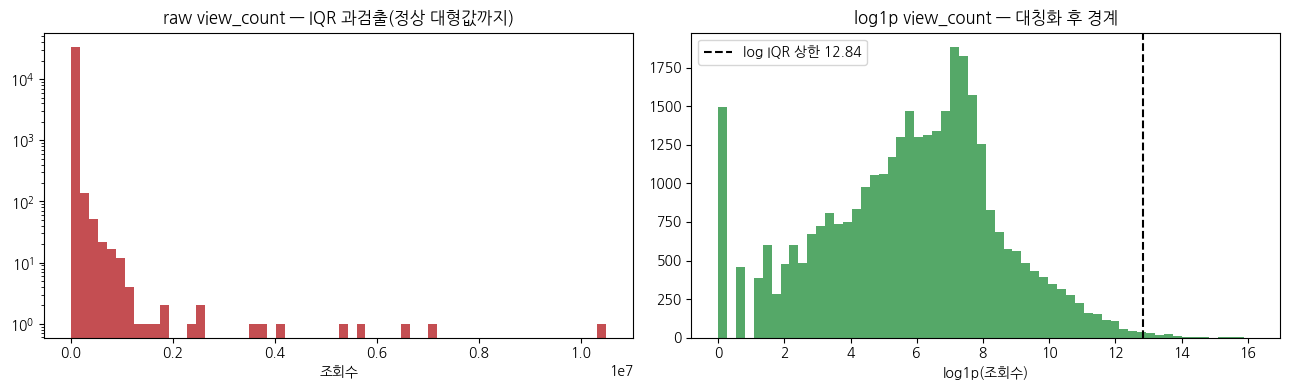

In [25]:
def log_iqr_outlier(s):
    """log1p 변환 후 IQR로 outlier 플래그 (raw 우편향 보정). 삭제 X, 플래그만."""
    sl = np.log1p(s.clip(lower=0))
    q1, q3 = sl.quantile(.25), sl.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((sl < lo) | (sl > hi)).astype(int), (lo, hi)

# 채널: 규모 변수 / 영상: 참여 변수에 log1p + IQR
ch_out = ['subscriber_count','video_count','view_count']
vd_out = ['view_count','like_count','comment_count','duration_seconds']

print('=== log1p+IQR outlier 비율 (Retention: 삭제 X, flag만) ===')
for c in ch_out:
    flag, (lo, hi) = log_iqr_outlier(ch[c]); ch[f'{c}_is_outlier'] = flag
    print(f'[channels] {c:18s} outlier {flag.mean()*100:5.1f}%  (log경계 {lo:.2f}~{hi:.2f})')
for c in vd_out:
    flag, (lo, hi) = log_iqr_outlier(vd[c]); vd[f'{c}_is_outlier'] = flag
    print(f'[videos]   {c:18s} outlier {flag.mean()*100:5.1f}%  (log경계 {lo:.2f}~{hi:.2f})')

# 시각화: raw IQR vs log1p IQR 경계 차이 (view_count 예시)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
s = vd['view_count'].clip(lower=0)
ax[0].hist(s, bins=60, color='#c44e52'); ax[0].set_yscale('log')
ax[0].set_title('raw view_count — IQR 과검출(정상 대형값까지)'); ax[0].set_xlabel('조회수')
ax[1].hist(np.log1p(s), bins=60, color='#55a868')
qlo, qhi = log_iqr_outlier(vd['view_count'])[1]
ax[1].axvline(qhi, color='k', ls='--', label=f'log IQR 상한 {qhi:.2f}')
ax[1].set_title('log1p view_count — 대칭화 후 경계'); ax[1].set_xlabel('log1p(조회수)'); ax[1].legend()
plt.tight_layout(); plt.show()

#### 4-3. Anomaly processing
**목적**: 정상 패턴을 이탈한 관측을 **Retention**(삭제 X, flag)으로 보존 — 본 프로젝트에서 anomaly = 타깃 신호(작전성·봇·유령) → H1 분류·H2 군집의 핵심 입력.

**방법**: outlier(4-2, *단변량 분포*의 극단)와 달리 anomaly는 *규칙·맥락*의 이탈(구독 대비 조회 과다, 좋아요>조회)을 규칙선·도메인 조건으로 탐지해 flag.

**결과 + 처리**

| anomaly | 정의 | 개수 | 처리 |
|---|---|---|---|
| 유령/비활성 | 구독0&조회0 또는 영상0 | 252 | `is_inactive` flag |
| 규칙 이탈 | 구독~조회 규칙선 이탈(3-3-3) | 54(2.7%) | `is_rule_anomaly` flag |
| 비정상 참여 | `like_rate>1`(좋아요>조회) | 19 | `like_rate_anomaly` flag |
| 수집 결함 | `video_age_days<0`(게시>수집) | 0 | 발견 시에만 삭제 |

**결론**
- 수집 결함(0개)만 삭제 대상, 나머지는 보존+flag 후 4-4에서 채널 feature로 합친다.
- **`view`=0 영상의 참여율은 0이 아니라 결측(NaN)**: `view`=0은 조회 미집계지 진짜 무반응이 아님(3-2-3 — view=0인데 댓글 184·좋아요 49 존재). 0으로 강제하면 채널 median(4-4)이 인위적으로 낮아져 정상/의심 구분을 흐림 → NaN으로 두고 median 집계에서 자동 제외.


In [26]:
# ---- 채널 anomaly ----
# 유령/비활성: 구독자0&조회0 또는 영상0
ch['is_inactive'] = (((ch['subscriber_count'] == 0) & (ch['view_count'] == 0))
                     | (ch['video_count'] == 0)).astype(int)
# 규칙 이탈(3-3-3 재현): 구독자~조회 로그-로그 규칙선에서 |잔차|>2.5σ
m = (ch['subscriber_count'] > 0) & (ch['view_count'] > 0)
ch['is_rule_anomaly'] = 0
xx, yy = np.log1p(ch.loc[m, 'subscriber_count']), np.log1p(ch.loc[m, 'view_count'])
coef = np.polyfit(xx, yy, 1); resid = yy - np.polyval(coef, xx)
ch.loc[m, 'is_rule_anomaly'] = (resid.abs() > 2.5 * resid.std()).astype(int)

# ---- 영상 anomaly + 파생 feature ----
vd_pub = pd.to_datetime(vd['published_at'], format='ISO8601', utc=True)
vd_col = pd.to_datetime(vd['collected_at'], format='ISO8601', utc=True)
vd['video_age_days'] = (vd_col - vd_pub).dt.total_seconds() / 86400
n_bad = int((vd['video_age_days'] < 0).sum())
print(f'수집 결함(age<0): {n_bad}개 → {"삭제" if n_bad else "없음(삭제 불필요)"}')
vd = vd[vd['video_age_days'] >= 0].copy()           # 데이터 오류만 삭제(없으면 무변화)

# 참여 비율: view==0은 미집계(진짜 0 아님, 3-2-3 근거) → 0 강제 시 채널 median 왜곡 → 결측(NaN)으로 두고 집계서 제외
_view = vd['view_count'].replace(0, np.nan)   # 분모 0 → NaN (0division·inf 방지)
vd['like_rate']    = vd['like_count']    / _view
vd['comment_rate'] = vd['comment_count'] / _view
vd['like_rate_anomaly'] = (vd['like_rate'] > 1).astype(int)   # 좋아요>조회 = 비정상
vd['is_short']     = (vd['duration_seconds'] <= 180).astype(int)   # 3-2-4와 통일(YouTube Shorts 정책 180s)
vd['has_comments'] = (vd['comment_count'] > 0).astype(int)
# 업로드 시각대(KST, 3-2-5) → H3 시황민감도 채널 feature(장중 vs 장마감후)
_kst_hr = pd.to_datetime(vd['published_at'], format='ISO8601', utc=True).dt.tz_convert('Asia/Seoul').dt.hour
vd['is_market_hours'] = _kst_hr.between(9, 15).astype(int)    # 장중 9~15시
vd['is_after_market'] = _kst_hr.between(16, 20).astype(int)   # 장마감후 16~20시

# ---- 모델 입력용 log1p feature (H2 군집/PCA 스케일 보정) ----
for c in ['subscriber_count','video_count','view_count']:
    ch[f'log_{c}'] = np.log1p(ch[c].clip(lower=0))
for c in ['view_count','like_count','comment_count','duration_seconds']:
    vd[f'log_{c}'] = np.log1p(vd[c].clip(lower=0))

# 채널 나이(3-2-6) → 성숙도 feature + 신생 flag(리딩방 신생 가설)
_ch_age = (pd.to_datetime(ch['collected_at'], format='ISO8601', utc=True)
           - pd.to_datetime(ch['published_at'], format='ISO8601', utc=True)).dt.total_seconds() / 86400
ch['channel_age_days'] = _ch_age
ch['is_new_channel'] = (_ch_age < 365).astype(int)

print('channels anomaly: 비활성', int(ch['is_inactive'].sum()),
      '| 규칙이탈', int(ch['is_rule_anomaly'].sum()))
print('videos anomaly: like_rate>1', int(vd['like_rate_anomaly'].sum()),
      '| shorts', int(vd['is_short'].sum()), '| 댓글있음', int(vd['has_comments'].sum()))

수집 결함(age<0): 0개 → 없음(삭제 불필요)
channels anomaly: 비활성 252 | 규칙이탈 54
videos anomaly: like_rate>1 19 | shorts 16986 | 댓글있음 15891


#### 4-4. 분석용 데이터셋 조립 & 저장
**목적**: 전처리 결과를 정제 테이블 3개 + **채널 단위 모델링 매트릭스**로 저장.

**방법**: H1·H2·H3 모두 분석 단위 = **채널**(리딩방=채널) → 영상 참여지표를 채널별 집계(중앙값 — 우편향이라 평균 대신)하고, 댓글 행동(3-2-8)·연락처 형식 플래그(3-2-9)·첫댓글 시딩(3-3-4)·업로드 시각대(3-2-5 H3)를 채널 단위로 합쳐 메타·flag와 결합.

**결과 — 산출물** (`data/processed/`)

| 파일 | 내용 |
|---|---|
| `channels_clean` | 채널 + 결측/outlier/anomaly flag + log feature + 채널나이 |
| `videos_clean` | 영상 + 참여비율 + age + 시각대 flag |
| `comments_clean` | 댓글 + `is_reply` + `has_like` |
| `channel_features` | 채널단위 ML 입력(H1/H2/H3) |
| `channel_labels` | `search_query`(약한 라벨 prior) — **누수 차단 위해 feature서 분리**, 평가·시드라벨 전용 |

EDA에서 신호로 짚은 feature를 채널 단위로 추가: 댓글행동(`author_uniq`·`text_uniq`·`reply_rate`·`comment_n`), 연락처 개별 플래그(`has_url`·`has_kakao`·`has_phone`·`has_telegram`·`has_band`·`has_email`), 첫댓글 중앙시간(`med_ttf_hours`), 업로드 시각대 비율(`market_hours_ratio`·`after_market_ratio`), 채널나이(`channel_age_days`·`is_new_channel`). `has_contact`(OR 합성)는 다중공선성으로 **제외**(3-2-9).

**결론**
- 원본 DB는 건드리지 않고 csv로 별도 저장(TermProject1 제출 dataset 포함).
- **표준화(StandardScaler)는 여기서 적용하지 않는다**: PCA(H2)·거리기반 군집은 표준화가 필요하나 train/test 분리 *후* fit해야 누수가 없으므로 모델링 단계에서 수행. log feature는 분포 보정용(표준화와 별개).
- 댓글·시딩 feature는 댓글 없는 채널에서 NaN → 모델 입력 전 결측 처리(중앙값 대치 또는 결측 flag) 필요. `comment_n`으로 신뢰 게이팅 가능.


In [27]:
# ---- 채널 단위 모델링 매트릭스: 영상 참여지표를 채널별 집계(중앙값=우편향에 안 흔들림) ----
vid_agg = vd.groupby('channel_id').agg(
    n_videos_collected=('video_id', 'size'),
    med_view=('view_count', 'median'),
    med_like=('like_count', 'median'),
    med_comment=('comment_count', 'median'),
    med_like_rate=('like_rate', 'median'),
    med_comment_rate=('comment_rate', 'median'),
    short_ratio=('is_short', 'mean'),
    has_comments_ratio=('has_comments', 'mean'),
    med_age_days=('video_age_days', 'median'),
    like_rate_anomaly_ratio=('like_rate_anomaly', 'mean'),
    market_hours_ratio=('is_market_hours', 'mean'),
    after_market_ratio=('is_after_market', 'mean'),
).reset_index()

# 댓글 행동 채널 집계(3-2-8): 작성자/텍스트 고유율·대댓글율 + comment_n(신뢰 게이팅용)
_cg = cm.groupby('channel_id')
_cn = _cg.size()
cmt_beh = pd.DataFrame({
    'comment_n'  : _cn,
    'author_uniq': _cg['author'].nunique() / _cn,
    'text_uniq'  : _cg['text'].nunique() / _cn,
    'reply_rate' : _cg['is_reply'].mean(),
})

# search_query는 약한 라벨 prior(누수) → feature 매트릭스서 분리, 평가·시드라벨 전용 파일로만 저장
ch_meta = ['channel_id','title','is_kr','has_description',
           'subscriber_count','video_count','view_count',
           'log_subscriber_count','log_video_count','log_view_count',
           'channel_age_days','is_new_channel',
           'is_inactive','is_rule_anomaly',
           'subscriber_count_is_outlier','view_count_is_outlier']
channel_features = (ch[ch_meta]
    .merge(vid_agg, on='channel_id', how='left')
    .merge(cmt_beh,    left_on='channel_id', right_index=True, how='left')   # 댓글 행동(3-2-8)
    .merge(chan_flags, left_on='channel_id', right_index=True, how='left')   # 연락처 개별 플래그(3-2-9)
    .merge(chan_ttf,   left_on='channel_id', right_index=True, how='left'))  # 첫댓글 시딩(3-3-4)

# ---- 저장 (원본 DB 보존, processed/ 별도) ----
from pathlib import Path
out = Path('/home/songyaeji/stockguard_for_youtube/data/processed'); out.mkdir(parents=True, exist_ok=True)

def save(df, name):
    df.to_csv(out / f'{name}.csv', index=False)
    try:
        df.to_parquet(out / f'{name}.parquet', index=False)   # pyarrow 있으면
    except Exception as e:
        print(f'  (parquet 건너뜀: {type(e).__name__})')

# 라벨 누수 차단: search_query(약한 라벨 prior) 별도 파일 — 평가·시드라벨 전용, feature 아님
channel_labels = ch[['channel_id','title','search_query']].copy()

save(ch, 'channels_clean')
save(vd, 'videos_clean')
save(cm, 'comments_clean')
save(channel_features, 'channel_features')
save(channel_labels, 'channel_labels')

print('저장 완료 →', out)
print(f'  channels_clean   {ch.shape}')
print(f'  videos_clean     {vd.shape}')
print(f'  comments_clean   {cm.shape}')
print(f'  channel_features {channel_features.shape}  ← ML 입력(H1/H2/H3)')
display(channel_features.head(3))

  (parquet 건너뜀: ImportError)


  (parquet 건너뜀: ImportError)


  (parquet 건너뜀: ImportError)
  (parquet 건너뜀: ImportError)
  (parquet 건너뜀: ImportError)
저장 완료 → /home/songyaeji/stockguard_for_youtube/data/processed
  channels_clean   (2508, 25)
  videos_clean     (34162, 29)
  comments_clean   (423522, 11)
  channel_features (2508, 39)  ← ML 입력(H1/H2/H3)


,channel_id,title,is_kr,has_description,subscriber_count,video_count,view_count,log_subscriber_count,log_video_count,log_view_count,...,author_uniq,text_uniq,reply_rate,has_url,has_kakao,has_phone,has_telegram,has_band,has_email,med_ttf_hours
0,UCzcy0PURMktW2BBgNpih-rw,청담개미여왕,0,1,83,35,36736,4.430817,3.583519,10.511540,...,0.294118,1.000000,0.352941,False,False,False,False,False,False,13.621944
1,UCAcesv8qLL5-4BLI6bhHKxg,주식명사수 주명,1,1,15000,131,1680579,9.615872,4.882802,14.334650,...,0.496296,0.851852,0.118519,False,True,False,True,False,True,0.008611
2,UC0HOU_uMrAmnT4U5VMnqpKg,주식실세,1,0,1020,2,177,6.928538,1.098612,5.181784,...,NaN,NaN,NaN,False,False,False,False,False,False,NaN
